<a href="https://colab.research.google.com/github/sunitharamu-1983/GENAI-Learning-Journey/blob/main/Thirukkural_GPT_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚒ Notebook 1 of 2 — GPT From Scratch: PyTorch Deep Dive
### Thirukkural Edition · Build Every Layer by Hand · Understand the Math · See Every Tensor

<a href="https://colab.research.google.com/github/nursnaaz/zero-to-genai-engineer/blob/main/03_GPT_Evolution_and_Alignment/notebooks/NB1_GPT_PyTorch_Detailed_Holmes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

## Ÿ Why Are There Two Notebooks?

| | **f4d2 This Notebook (NB1)** | **f4d2 Notebook 2 (NB2)** |
|---|---|---|
| **Title** | GPT From Scratch: PyTorch Deep Dive (Thirukkural) | GPT Pipeline Overview: TensorFlow/Keras |
| **Framework** | PyTorch | TensorFlow / Keras |
| **Approach** | Build every layer from scratch — you write the math | High-level API — Keras handles the internals |
| **Code depth** | ~1,800 lines · 28 code cells | ~435 lines · 10 code cells |
| **Tokenizer** | Char / Word / BPE — three modes, you choose | Character-level only |
| **Architecture** | `CausalSelfAttention`, `FeedForward`, `GPT` — all hand-coded | `MultiHeadAttention`, `Dense` — Keras built-ins |
| **Dataset** | Thirukkural (680 K chars) | Short synthetic sentences (Space / Ocean / Medieval) |
| **Generation** | Token-by-token with live top-5 display + attention heatmap | Single generate call |
| **Best for** | Deep understanding of **HOW** GPT works | Quick mental map of the **WHAT** (the pipeline) |

### f3af The Learning Path

```
Start with NB2 (TensorFlow)   →   Get the big picture in 30 min
Then do  NB1 (PyTorch)        →   Understand every line of that picture
```

> **If you only have time for one:** do this notebook (NB1).  
> PyTorch is the industry standard for GenAI research and production.

---

**By the end of this notebook you will:**
- Understand exactly how GPT learns to predict the next token
- Build every component from scratch — embedding, attention, feed-forward, transformer block
- Train on ~480K characters of Sherlock Holmes stories and watch loss fall
- See text generated **token by token** with the top-5 candidates shown at every step
- Fine-tune the same model for sentiment classification

---

## f5fa  The Journey

```
STEP 1  →  Load Thirukkural (680K chars)
STEP 2  →  Build tokenizer: Char / Word / BPE — you choose
STEP 3  →  Create sliding-window training pairs
STEP 4  →  Build GPT: Embedding + CausalAttention + FeedForward × 4
STEP 5  →  Pre-train with AdamW + cosine LR + gradient clipping
STEP 6  →  Generate token by token — watch every decision live
STEP 7  →  Fine-tune the backbone for sentiment classification
```

**Framework:** PyTorch (transparent — no magic hiding)  
**Dataset:** Thirukkural (Project Gutenberg, ~480 KB)  
**Model:** ~2M parameters — trains in 5–10 min on Colab GPU, ~25 min on CPU


In [ ]:
# Install required packages
# (already present in Colab — only needed if running locally)
!pip install torch matplotlib numpy requests tqdm tiktoken --quiet
print("✅ All packages ready")


✅ All packages ready


In [ ]:
import torch                          # PyTorch deep learning engine
import torch.nn as nn                 # Neural network building blocks
import torch.nn.functional as F       # Activation functions and losses
import math                           # sqrt() for attention scaling
import numpy as np                    # Numerical helpers
import matplotlib.pyplot as plt       # Plotting
import requests                       # HTTP download
import time                           # Timing training
import os                             # File path helpers
from dataclasses import dataclass     # Clean hyperparameter storage
from torch.utils.data import Dataset, DataLoader  # Data pipeline

# Fix random seeds so results are reproducible
torch.manual_seed(42)
np.random.seed(42)

print("✅ Imports complete")
print(f"   PyTorch version: {torch.__version__}")


✅ Imports complete
   PyTorch version: 2.10.0+cu128


In [ ]:
# Auto-detect GPU — Colab provides a free T4 GPU
# Go to: Runtime → Change runtime type → T4 GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Using: {device.upper()}")
if device == 'cuda':
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   ⚠️  No GPU found — training will take ~25 min on CPU.")
    print("   Colab tip: Runtime → Change runtime type → T4 GPU (free)")


🖥️  Using: CUDA
   GPU : Tesla T4
   VRAM: 15.6 GB


## 📚 STEP 1 — Dataset: The Foundation of Learning

We train on **The Adventures of Sherlock Holmes** by Arthur Conan Doyle — twelve complete mystery stories downloaded from Project Gutenberg (~480K characters, published 1892, public domain).

Why Sherlock Holmes?
- **Unmistakable voice**: Holmes's logical deductions and Watson's narration are instantly recognisable — you will know immediately when the output sounds right
- **Modern English**: Written in the 1890s — clear sentences, no archaic thee/thou confusion. Easy to read for non-native English speakers
- **Global recognition**: Known in 100+ countries through books, BBC/Netflix adaptations, films — no cultural background required
- **Rich structure**: Each story has a mystery → investigation → reveal arc that gives the model real narrative patterns to learn

This notebook supports **three tokenization modes** (set `TOKENIZER_TYPE` in the next section):

| Mode | `TOKENIZER_TYPE` | Vocab | Context (128 tokens) |
|------|-----------------|-------|---------------------|
| Character | `'char'` | ~65 | ~20 words |
| **Word** (default) | `'word'` | ~15 K | **~128 words** ← recommended |
| BPE (GPT-2) | `'bpe'` | 50 257 | ~50 words |

**Word-level example:**
```
"Holmes said\n" → ['Holmes', 'said', '\n'] → [1842, 4521, 3]
```

After training, GPT predicts the next token given all previous ones.  
The model has never been told anything about English — it infers everything from patterns.


In [ ]:
print("⬇️  Downloading Thirukkural...")

# ── Bulletproof download — tries two Gutenberg URLs ──────────────────────────
import requests

URLS = [
    "https://raw.githubusercontent.com/b1zantine/thirukkural-dataset/master/thirukkural.txt",
]

raw_text = None
for url in URLS:
    try:
        r = requests.get(url, timeout=30)
        # Validate: must be plain text and at least 80K chars for Thirukkural
        if r.status_code == 200 and len(r.text) > 80_000:
            raw_text = r.text
            print(f"   Source: {url}")
            break
        else:
            print(f"   Skipped {url}: status={r.status_code} len={len(r.text)}")
    except Exception as e:
        print(f"   Skipped {url}: {e}")

if raw_text is None:
    raise RuntimeError(
        "Could not download Thirukkural text from the provided URL.\n"
        "Check your internet connection, then re-run this cell."
    )

# ── Strip BOM and apply minimal cleaning for Thirukkural ─────────────────────
raw_text = raw_text.lstrip("\ufeff")   # remove BOM (byte-order mark) if present

# For Thirukkural, the entire downloaded text is usually the content.
# We'll just assign raw_text to text directly.
text = raw_text

# ── Sanity check ─────────────────────────────────────────────────────────────
assert len(text) > 50_000, f"Text too short ({len(text)} chars) — download may have failed"

print(f"✅ Downloaded and cleaned: {len(text):,} characters")
print(f"   ≈ {len(text.split()):,} words  |  Thirukkural dataset")
print()
print("─" * 60)
print("First 300 characters of story content:")
print("─" * 60)
print(text[:300])
print("─" * 60)


⬇️  Downloading Thirukkural...
   Source: https://raw.githubusercontent.com/b1zantine/thirukkural-dataset/master/thirukkural.txt
✅ Downloaded and cleaned: 81,698 characters
   ≈ 8,069 words  |  Thirukkural dataset

────────────────────────────────────────────────────────────
First 300 characters of story content:
────────────────────────────────────────────────────────────
அகர முதல எழுத்தெல்லாம் ஆதி$பகவன் முதற்றே உலகு.
கற்றதனால் ஆய பயனென்கொல் வாலறிவன்$நற்றாள் தொழாஅர் எனின்.
மலர்மிசை ஏகினான் மாணடி சேர்ந்தார்$நிலமிசை நீடுவாழ் வார்.
வேண்டுதல் வேண்டாமை இலானடி சேர்ந்தார்க்கு$யாண்டும் இடும்பை இல.
இருள்சேர் இருவினையும் சேரா இறைவன்$பொருள்சேர் புகழ்புரிந்தார் மாட்டு.
பொறிவாயில
────────────────────────────────────────────────────────────


In [ ]:
from collections import Counter

unique_chars = sorted(set(text))
print(f"Ŵ Unique characters: {len(unique_chars)}")
print(f"   {repr(''.join(unique_chars))}")
print()

char_counts = Counter(text)
print("📊 Top 10 most frequent characters:")
for ch, cnt in char_counts.most_common(10):
    bar = '█' * (cnt // 10000)
    print(f"  {repr(ch):6s}  {cnt:8,}  {bar}")

print()
print("❖ Scale comparison:")
print(f"  This dataset : {len(text)/1e6:.2f}M chars")
print(f"  GPT-1 trained: ~4,600M chars  (×4600 bigger)")
print(f"  GPT-3 trained: ~300,000M chars  (×270,000 bigger)")
print()
print("ı Even with ~573K chars our mini-GPT will produce Thirukkural-style text!")


Ŵ Unique characters: 16
   ' அகஙடணமயறலளவாிு்'

📊 Top 10 most frequent characters:
  '்'            5  
  'ு'            3  
  'க'            2  
  'ள'            2  
  ' '            2  
  'ம'            2  
  'ண'            1  
  'ட'            1  
  'ா'            1  
  'ல'            1  

❖ Scale comparison:
  This dataset : 0.00M chars
  GPT-1 trained: ~4,600M chars  (×4600 bigger)
  GPT-3 trained: ~300,000M chars  (×270,000 bigger)

ı Even with ~573K chars our mini-GPT will produce Thirukkural-style text!


## 🔢 STEP 2 — Tokenizer: Text ↔ Numbers

Neural networks only understand numbers, so we need a mapping:

```
encode("Hello") → [20, 43, 50, 50, 53]    text → integers (model input)
decode([20, 43, 50, 50, 53]) → "Hello"    integers → text  (reading output)
```

### Three tokenisation strategies — you can switch between them

| Strategy | Example | Vocab | Context (128 tokens) | Notes |
|----------|---------|-------|----------------------|-------|
| **Character** `'char'` | `"hello"` → `[h,e,l,l,o]` | ~65 | ~20 words | simple baseline; struggles with long-range structure |
| **Word** `'word'` ← default | `"hello"` → `[hello]` | ~25 K | ~128 words | one full paragraph; output is always real words |
| **BPE** `'bpe'` | `"hello"` → `[hel,lo]` | ~10 K | ~50 words | exact strategy used by GPT-2/3/4 |

Set `TOKENIZER_TYPE` in the next cell to choose.  
Everything downstream (dataset, model, training, generation) adapts automatically.

### Why word-level produces better output

With character-level, a context window of 128 tokens covers only ~20 words.  
The model has to learn to spell words **and** form sentences in a tiny window.

With word-level, the same window covers **128 whole words** — a full paragraph.  
The model focuses entirely on word sequences; generated text is always real vocabulary.

### How BPE works (the GPT-2 approach)

Start with characters, then iteratively merge the most-frequent adjacent pair:

```
Iteration 1: 't' + 'h' → 'th'   (very common in English)
Iteration 2: 'th' + 'e' → 'the'  (even more common)
Iteration 3: 'i' + 'n' → 'in'
…
```

The result: common words become single tokens, rare words split into subwords.  
This notebook wraps OpenAI's `tiktoken` (GPT-2 merges) but remaps to the ~10 K tokens  
that actually appear in the Holmes stories, keeping training fast.


In [ ]:
import re as _re

# ══════════════════════════════════════════════════════════════════════════════
#  TOKENIZER CHOICE — the only line you need to change
#
#   'char'  →  character-level   vocab ~65       original demo (letter by letter)
#   'word'  →  word-level        vocab ~15 K     one token per word  ← default
#   'bpe'   →  byte-pair (GPT-2) vocab  50,257   subword merges like real GPT-2
# ══════════════════════════════════════════════════════════════════════════════
TOKENIZER_TYPE = 'char'    # ← change me to 'char', 'word', or 'bpe'


# ─── Strategy 1: Character-level (original baseline) ─────────────────────────
# Every unique character is one token.  Vocab = 65 chars.
# A context window of 128 chars covers only ~20 words — limited long-range structure.
# Kept here as a reference; try 'word' or 'bpe' for much more coherent output.

class CharTokenizer:
    """
    Character-level tokenizer — maps each character to a unique integer.
    Analogy: a secret codebook, one entry per letter/symbol.
    """
    def __init__(self, text):
        chars = sorted(set(text))
        self.vocab_size = len(chars)
        self.char_to_idx = {ch: i for i, ch in enumerate(chars)}
        self.idx_to_char = {i: ch for i, ch in enumerate(chars)}
        print(f"CharTokenizer: {self.vocab_size} unique characters")

    def encode(self, text):
        # Note: Holmes text has ~70 chars; some punctuation variants may be rare.
        # Holmes text uses arabic digits occasionally (years, counts, etc.).
        unknown = sorted(set(ch for ch in text if ch not in self.char_to_idx))
        if unknown:
            print(f"⚠️  encode: skipping {len(unknown)} unknown char(s): {unknown}")
        return [self.char_to_idx[ch] for ch in text if ch in self.char_to_idx]

    def decode(self, indices):
        return ''.join(self.idx_to_char[i] for i in indices)


# ─── Strategy 2: Word-level ───────────────────────────────────────────────────
# Each word and punctuation mark is one token.
# 'To be, or not' → ['To', 'be', ',', 'or', 'not']   (5 tokens, not 14 chars)
#
# A 128-token context window now covers 128 WORDS — a full paragraph.
# Generated text is always composed of real Holmes words → much more readable.
# Trade-off: vocab ≈ 15 K, so n_embd is auto-widened in the config cell below.

class WordTokenizer:
    """
    Word-level tokenizer: splits into words (including apostrophes) and punctuation.
    Regex pattern: sequences of letters/apostrophes  OR  single punctuation  OR  newline.
    """
    _PATTERN = _re.compile(r"[A-Za-z']+|[^A-Za-z'\s]|\n")

    def __init__(self, text):
        tokens = self._PATTERN.findall(text)
        vocab = sorted(set(tokens))
        self.vocab_size = len(vocab)
        self.word_to_idx = {w: i for i, w in enumerate(vocab)}
        self.idx_to_word = {i: w for i, w in enumerate(vocab)}
        print(f"WordTokenizer: {len(tokens):,} tokens · {self.vocab_size:,} unique words/punct")

    def encode(self, text):
        tokens = self._PATTERN.findall(text)
        unknown = sorted(set(t for t in tokens if t not in self.word_to_idx))
        if unknown:
            print(f"⚠️  encode: {len(unknown)} unknown token(s) skipped: {unknown[:5]}")
        return [self.word_to_idx[t] for t in tokens if t in self.word_to_idx]

    def decode(self, indices):
        out = ''
        for tok in tokens:
            if not out:
                out = tok
            elif tok == '\n':
                out += '\n'             # newline: no preceding space
            elif out.endswith('\n'):
                out += tok              # first token after newline: no space
            elif _re.match(r"[A-Za-z']", tok):
                out += ' ' + tok        # word token: add space before
            else:
                out += tok              # punctuation: attach directly (no space)
        return out


# ─── Strategy 3: Byte-Pair Encoding via tiktoken ─────────────────────────────
# The exact approach used by GPT-2/3/4: start with characters, merge frequent pairs.
# This uses tiktoken (OpenAI's fast BPE library) with the full GPT-2 vocabulary.
#
# Full GPT-2 vocab: 50,257 tokens.
# Holmes uses only ~8K of them — the rest get near-zero probability during
# generation and are effectively ignored, but keeping the full vocab avoids
# any round-trip encoding artifacts.
#
# Trade-off: large vocab → model auto-uses n_embd=128 to stay manageable (~15 M params).

class BPETokenizer:
    """GPT-2 BPE tokenizer via tiktoken — full 50,257-token vocabulary."""

    def __init__(self, text):
        try:
            import tiktoken
        except ImportError:
            raise ImportError("tiktoken not found — run: !pip install tiktoken")
        self._enc = tiktoken.get_encoding("gpt2")
        self.vocab_size = self._enc.n_vocab        # always 50,257
        full_ids = self._enc.encode(text)
        used = len(set(full_ids))
        print(f"BPETokenizer: GPT-2 vocab = {self.vocab_size:,} tokens")
        print(f"   Holmes text uses {used:,} of {self.vocab_size:,} tokens in training")
        print(f"   Unused tokens get near-zero probability during generation (harmless)")

    def encode(self, text):
        # tiktoken handles all text — no OOV possible with BPE
        return self._enc.encode(text)

    def decode(self, indices):
        return self._enc.decode(indices)


# ─── Select tokenizer and encode full corpus ─────────────────────────────────
_BUILDERS = {'char': CharTokenizer, 'word': WordTokenizer, 'bpe': BPETokenizer}
if TOKENIZER_TYPE not in _BUILDERS:
    raise ValueError(f"TOKENIZER_TYPE must be 'char', 'word', or 'bpe' — got {TOKENIZER_TYPE!r}")

tokenizer = _BUILDERS[TOKENIZER_TYPE](text)

# Encode the entire corpus as one long tensor of integers
data = torch.tensor(tokenizer.encode(text), dtype=torch.long)

_ctx_desc = {'char': '~20 words', 'word': '~128 words', 'bpe': '~50 words'}
print(f"\n✅ Active tokenizer : {TOKENIZER_TYPE.upper()}")
print(f"   Vocabulary size  : {tokenizer.vocab_size:,}")
print(f"   Data tensor      : {data.shape}  (one integer per token)")
print(f"   Context (128 tok): {_ctx_desc[TOKENIZER_TYPE]}")

CharTokenizer: 47 unique characters

✅ Active tokenizer : CHAR
   Vocabulary size  : 47
   Data tensor      : torch.Size([81698])  (one integer per token)
   Context (128 tok): ~20 words


In [ ]:
# ── Verify the tokenizer works correctly ─────────────────────────────────────
sample = "அகர முதல எழுத்தெல்லாம் ஆதி பகவன் முதற்றே உலகு."

encoded = tokenizer.encode(sample)
decoded = tokenizer.decode(encoded)

print("🧪 Tokenizer round-trip test:")
print(f"  Tokenizer: {TOKENIZER_TYPE.upper()}")
print(f"  Original : {repr(sample[:45])}")
print(f"  Encoded  : {encoded[:10]}...")
print(f"  Decoded  : {repr(decoded[:45])}")
print(f"  Match    : {'✅ PASS' if decoded == sample else '❌ FAIL  → ' + repr(decoded[:45])}")

print()
# Show token → ID mapping in a way that makes sense for every tokenizer
if TOKENIZER_TYPE == 'char':
    # Char-level: one row per character
    print(f"📖 Character → ID mapping (first 20 characters):")
    print(f"  {'Char':^8}  {'ID':^6}")
    print("  " + "─" * 16)
    for ch, idx in zip(sample[:20], encoded[:20]):
        print(f"  {repr(ch):^8}  {idx:^6}")
else:
    # Word / BPE: one row per token (each encoded ID → its decoded string)
    n_show = min(15, len(encoded))
    print(f"📖 Token → ID mapping (first {n_show} tokens):")
    print(f"  {'Token':^18}  {'ID':^6}")
    print("  " + "─" * 26)
    for idx in encoded[:n_show]:
        tok = tokenizer.decode([idx])
        print(f"  {repr(tok):^18}  {idx:^6}")
    print(f"\n💡 {TOKENIZER_TYPE}-level: each token is a "
          f"{'word or punctuation mark' if TOKENIZER_TYPE == 'word' else 'subword unit'}.")
    print(f"   128-token context window covers "
          f"{'~128 words' if TOKENIZER_TYPE == 'word' else '~50 words'} "
          f"vs only ~20 words for char-level.")

🧪 Tokenizer round-trip test:
  Tokenizer: CHAR
  Original : 'அகர முதல எழுத்தெல்லாம் ஆதி பகவன் முதற்றே உலகு'
  Encoded  : [7, 18, 30, 1, 28, 39, 24, 32, 1, 13]...
  Decoded  : 'அகர முதல எழுத்தெல்லாம் ஆதி பகவன் முதற்றே உலகு'
  Match    : ✅ PASS

📖 Character → ID mapping (first 20 characters):
    Char      ID  
  ────────────────
    'அ'       7   
    'க'       18  
    'ர'       30  
    ' '       1   
    'ம'       28  
    'ு'       39  
    'த'       24  
    'ல'       32  
    ' '       1   
    'எ'       13  
    'ழ'       34  
    'ு'       39  
    'த'       24  
    '்'       46  
    'த'       24  
    'ெ'       41  
    'ல'       32  
    '்'       46  
    'ல'       32  
    'ா'       36  


---
### 🔄 NB1 vs NB2 — Step 2: Tokenization

| | 📓 **This notebook · NB1 · PyTorch** | 📓 NB2 · TensorFlow |
|---|---|---|
| **Modes** | `'char'` / `'word'` / `'bpe'` — switch with `TOKENIZER_TYPE` | Word-level only (one fixed approach) |
| **Vocab size** | 65 (char) · 14,565 (word) · 50,257 (BPE) | ~400 words (tiny synthetic corpus) |
| **OOV handling** | Skips unknown tokens with a printed warning | No OOV — closed vocabulary |
| **Code** | ~60 lines · 3 classes (`CharTokenizer`, `WordTokenizer`, `BPETokenizer`) | ~10 lines · `dict` lookup |
| **Context** | 128 tokens = ~20 words (char) or ~128 words (word) | 5 tokens (fixed `SEQ_LENGTH`) |

> 💡 **What you gain here:** Tokenization determines what the model "sees". Word-level gives whole words as atoms — 128 tokens = 128 words of context. BPE (what real GPT-2/3/4 use) splits unknowns into subwords. NB2 uses just one strategy to keep things simple.

---


## 🎯 STEP 3 — Training Data: The Sliding Window

From one text file we create thousands of training examples using a **sliding window**.

```
block_size = 8  (we look at 8 characters at once)

Text:   F  i  r  s  t     C  i  t  i  z  e  n  :

Window 1:
  Input : [F  i  r  s  t     C  i]
  Target: [i  r  s  t     C  i  t]   ← shifted one step right

Window 2 (slide by 1):
  Input : [i  r  s  t     C  i  t]
  Target: [r  s  t     C  i  t  i]

… 1,100,000 windows from ~1.1M characters
```

**Why shift by 1?**  
Because the task is: *given tokens 0..t, predict token t+1*.  
So `target[t] = input[t+1]` at every position — giving `block_size` training signals per window.


In [ ]:
class TextDataset(Dataset):
    """
    Sliding-window dataset.

    Each item is a (input, target) pair of length block_size,
    where target = input shifted one position to the right.
    """

    def __init__(self, data, block_size):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        # Every starting index from 0 to len(data)-block_size gives a valid window
        return len(self.data) - self.block_size

    def __getitem__(self, i):
        # Grab block_size+1 consecutive tokens
        chunk = self.data[i : i + self.block_size + 1]
        x = chunk[:-1]   # input:  tokens i   .. i+block_size-1
        y = chunk[1:]    # target: tokens i+1 .. i+block_size
        # At position t: model sees x[0..t] and must predict y[t] = x[t+1]
        return x, y


# ── Train / validation split ──────────────────────────────────────────────────
BLOCK_SIZE = 128    # context window length (characters)

n = int(0.9 * len(data))
train_data = data[:n]    # 90 % for training
val_data   = data[n:]    # 10 % for validation

train_dataset = TextDataset(train_data, BLOCK_SIZE)
val_dataset   = TextDataset(val_data,   BLOCK_SIZE)

print(f"✅ Datasets ready")
print(f"   block_size          : {BLOCK_SIZE} characters")
print(f"   Training tokens     : {len(train_data):,}")
print(f"   Validation tokens   : {len(val_data):,}")
print(f"   Training windows    : {len(train_dataset):,}")
print(f"   Validation windows  : {len(val_dataset):,}")


✅ Datasets ready
   block_size          : 128 characters
   Training tokens     : 73,528
   Validation tokens   : 8,170
   Training windows    : 73,400
   Validation windows  : 8,042


In [ ]:
# Peek at one training example to confirm the sliding window is correct
x_ex, y_ex = train_dataset[0]

print(f"🎓 One training example (block_size={BLOCK_SIZE}):")
print(f"   x shape: {x_ex.shape}  — the INPUT the model sees")
print(f"   y shape: {y_ex.shape}  — the TARGET the model must predict")
print()
print(f"  {'Pos':>5}  {'Input char':>12}  {'→  Target char':>14}")
print("  " + "─" * 36)
for t in range(12):
    in_ch  = tokenizer.decode([x_ex[t].item()])
    out_ch = tokenizer.decode([y_ex[t].item()])
    print(f"  {t:>5}  {repr(in_ch):>12}  →  {repr(out_ch):>12}")

print()
print("💡 At every position the model sees the input character and must predict")
print("   the target character one step ahead.")


🎓 One training example (block_size=128):
   x shape: torch.Size([128])  — the INPUT the model sees
   y shape: torch.Size([128])  — the TARGET the model must predict

    Pos    Input char  →  Target char
  ────────────────────────────────────
      0           'அ'  →           'க'
      1           'க'  →           'ர'
      2           'ர'  →           ' '
      3           ' '  →           'ம'
      4           'ம'  →           'ு'
      5           'ு'  →           'த'
      6           'த'  →           'ல'
      7           'ல'  →           ' '
      8           ' '  →           'எ'
      9           'எ'  →           'ழ'
     10           'ழ'  →           'ு'
     11           'ு'  →           'த'

💡 At every position the model sees the input character and must predict
   the target character one step ahead.


## 🏗️ STEP 4 — GPT Architecture: Building the Brain

```
INPUT token IDs   (B, T)
        │
        ▼
┌───────────────────────────────────────────────┐
│  Token Embedding   (vocab_size  → n_embd)     │  "What is this character?"
│  Position Embedding (block_size → n_embd)     │  "Where in the sequence?"
│  x = tok_emb + pos_emb                        │
└──────────────────────┬────────────────────────┘
                       │ Dropout
        ┌──────────────▼──────────────┐
        │     Transformer Block × 4   │
        │  ┌────────────────────────┐ │
        │  │  LayerNorm             │ │
        │  │  CausalSelfAttention   │ │  tokens look at each other
        │  │  + residual            │ │
        │  ├────────────────────────┤ │
        │  │  LayerNorm             │ │
        │  │  FeedForward (MLP)     │ │  each token processes info
        │  │  + residual            │ │
        │  └────────────────────────┘ │
        └──────────────┬──────────────┘
                       │
               LayerNorm (final)
                       │
        Output Head: Linear (n_embd → vocab_size)
                       │
OUTPUT logits   (B, T, vocab_size)
```

### Our Hyperparameters

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `vocab_size` | 70 | Unique characters in Holmes text |
| `block_size` | 128 | Context window (chars seen at once) |
| `n_embd` | 128 | Token vector dimension |
| `n_heads` | 4 | Parallel attention streams |
| `n_layers` | 4 | Stacked transformer blocks |
| `dropout` | 0.1 | Regularisation: zeros 10 % of activations |


In [ ]:
@dataclass
class GPTConfig:
    """All model hyperparameters in one place."""
    vocab_size : int   = 65     # unique tokens in vocabulary
    block_size : int   = 128    # maximum sequence length (context window)
    n_embd     : int   = 128    # embedding / hidden dimension
    n_heads    : int   = 4      # number of attention heads
    n_layers   : int   = 4      # number of stacked transformer blocks
    dropout    : float = 0.1    # dropout rate for regularisation


# ── Auto-tune model width to the vocabulary size ──────────────────────────────
# Why? The embedding table is vocab_size × n_embd and the output head is the same.
# We scale n_embd to give the model enough capacity to distinguish tokens.
#
#   Tokenizer │ vocab   │ n_embd │ n_heads │ approx total params
#   ──────────┼─────────┼────────┼─────────┼─────────────────────
#   char      │     65  │   128  │    4    │   ~2 M
#   word      │ ~15 K   │   256  │    8    │  ~10 M   (fast on T4)
#   bpe       │  50,257 │   128  │    4    │  ~15 M   (larger embed table)

if tokenizer.vocab_size <= 200:
    # Character-level: tiny vocab, compact model
    _n_embd, _n_heads = 128, 4
    _note = f"char-level vocab ({tokenizer.vocab_size}) → compact model"

elif tokenizer.vocab_size <= 30_000:
    # Word-level: medium vocab, widen model for better word representations
    _n_embd, _n_heads = 256, 8
    _note = f"word-level vocab ({tokenizer.vocab_size:,}) → wider model (n_embd=256)"

else:
    # BPE full vocab (50,257): large embedding table, keep n_embd moderate
    _n_embd, _n_heads = 128, 4
    _note = f"BPE full vocab ({tokenizer.vocab_size:,}) → moderate n_embd=128"

# Sanity check: n_embd must be divisible by n_heads
assert _n_embd % _n_heads == 0, f"n_embd {_n_embd} not divisible by n_heads {_n_heads}"

config = GPTConfig(
    vocab_size = tokenizer.vocab_size,
    block_size = BLOCK_SIZE,
    n_embd     = _n_embd,
    n_heads    = _n_heads,
    n_layers   = 4,
    dropout    = 0.1,
)

print(f"✅ GPT Config  (auto-tuned for {TOKENIZER_TYPE} tokenizer)")
print(f"   note            : {_note}")
for field, value in vars(config).items():
    print(f"   {field:<15} = {value}")


✅ GPT Config  (auto-tuned for char tokenizer)
   note            : char-level vocab (47) → compact model
   vocab_size      = 47
   block_size      = 128
   n_embd          = 128
   n_heads         = 4
   n_layers        = 4
   dropout         = 0.1


## 🔍 The Attention Mechanism — Tokens Talking to Each Other

### The Analogy: A Group Discussion

Imagine reading: `"The cat sat on the mat and it was tired"`

When processing **"it"**, the model needs to figure out what "it" refers to.  
It "asks" all previous words: *"Which of you am I about?"*  
- **"cat"** answers loudly → high attention weight  
- **"mat"** answers quietly → low attention weight  

This is **self-attention**: each token queries all previous tokens and collects a  
weighted sum of their information.

### Q, K, V — The Three Projections

Every token produces three vectors:

| Vector | Question it answers | Analogy |
|--------|--------------------|----|
| **Q** (Query) | "What am I looking for?" | A search query |
| **K** (Key) | "What do I contain?" | A document title |
| **V** (Value) | "What do I share if found?" | The document body |

```
Attention(Q, K, V) = softmax( Q Kᵀ / √head_size ) · V
                     ─────────────────────────────   ─────
                     Similarity scores (normalised)  Collected info
```

### "Causal" = No Peeking at the Future

At generation time, future tokens don't exist yet.  
We enforce this with a **lower-triangular mask** — future positions get −∞  
before softmax, which makes them contribute zero to every attention output.

```
Position →  0  1  2  3  4
         0: 1  ·  ·  ·  ·     ·  = masked (−∞ → 0 after softmax)
         1: 1  1  ·  ·  ·
         2: 1  1  1  ·  ·
         3: 1  1  1  1  ·
         4: 1  1  1  1  1
```

### "Multi-Head" = Run Attention Multiple Times in Parallel

We split the embedding into `n_heads` chunks and run attention independently.  
Each head can specialise: one tracks grammar, another tracks topic, etc.


In [ ]:
class CausalSelfAttention(nn.Module):
    """
    Multi-Head Causal Self-Attention.

    'Causal'     — each token can only look at itself and earlier tokens.
    'Self'       — tokens attend to other tokens in the SAME sequence.
    'Multi-Head' — repeat the process n_heads times in parallel, each
                   specialising in different relationship patterns.
    """

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_heads == 0, (
            f"n_embd ({config.n_embd}) must be divisible by n_heads ({config.n_heads})"
        )

        self.n_heads   = config.n_heads
        self.n_embd    = config.n_embd
        # Each head operates on a slice of the full embedding
        self.head_size = config.n_embd // config.n_heads

        # One linear layer computes Q, K, V for ALL heads simultaneously.
        # Output is 3 × n_embd; we split it into three equal parts afterwards.
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=False)

        # After each head produces its output, project back to n_embd
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=False)

        self.attn_drop  = nn.Dropout(config.dropout)
        self.resid_drop = nn.Dropout(config.dropout)

        # The causal mask: lower-triangular matrix of 1s.
        # register_buffer → saved in model state but NOT a learnable parameter.
        # Shape (1, 1, T, T) so it broadcasts over (batch, heads, T, T).
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(config.block_size, config.block_size))
                  .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, T, C = x.shape   # batch, time (sequence length), channels (n_embd)

        # ── 1. Compute Q, K, V all at once ───────────────────────────────────
        # c_attn maps (B, T, C) → (B, T, 3C); split into three (B, T, C) tensors
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)

        # ── 2. Reshape into multi-head form ──────────────────────────────────
        # (B, T, C) → (B, T, n_heads, head_size) → (B, n_heads, T, head_size)
        def split_heads(t):
            return t.view(B, T, self.n_heads, self.head_size).transpose(1, 2)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        # ── 3. Scaled dot-product attention ──────────────────────────────────
        # scale prevents dot products from growing so large that softmax saturates
        scale = 1.0 / math.sqrt(self.head_size)
        att = (q @ k.transpose(-2, -1)) * scale     # (B, n_heads, T, T)

        # ── 4. Apply causal mask — block attending to future tokens ──────────
        # masked_fill: wherever mask==0 (future), set score to -∞
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))

        # ── 5. Softmax → attention weights (probabilities summing to 1) ───────
        att = F.softmax(att, dim=-1)                 # (B, n_heads, T, T)
        att = self.attn_drop(att)

        # ── 6. Weighted sum of values ─────────────────────────────────────────
        # Each position collects a weighted blend of all visible value vectors
        out = att @ v                                # (B, n_heads, T, head_size)

        # ── 7. Merge heads back into a single embedding ───────────────────────
        # (B, n_heads, T, head_size) → (B, T, n_embd)
        out = out.transpose(1, 2).contiguous().view(B, T, C)

        # ── 8. Output projection + dropout ───────────────────────────────────
        out = self.resid_drop(self.c_proj(out))

        # Return both output AND raw attention weights (used later for visualisation)
        return out, att


print("✅ CausalSelfAttention defined")

# Quick shape check
_cfg  = GPTConfig(vocab_size=65, block_size=32, n_embd=32, n_heads=4, n_layers=2)
_attn = CausalSelfAttention(_cfg)
_x    = torch.randn(2, 10, 32)        # batch=2, seq_len=10, embd=32
_out, _att = _attn(_x)
print(f"   Input shape           : {tuple(_x.shape)}")
print(f"   Output shape          : {tuple(_out.shape)}  (same as input ✓)")
print(f"   Attention weight shape: {tuple(_att.shape)}  (batch, heads, seq, seq ✓)")


✅ CausalSelfAttention defined
   Input shape           : (2, 10, 32)
   Output shape          : (2, 10, 32)  (same as input ✓)
   Attention weight shape: (2, 4, 10, 10)  (batch, heads, seq, seq ✓)


---
### 🔄 NB1 vs NB2 — Step 4a: Attention Mechanism

| | 📓 **This notebook · NB1 · PyTorch** | 📓 NB2 · TensorFlow |
|---|---|---|
| **Implementation** | Hand-coded: Q/K/V projections, scaled dot-product, causal mask, dropout | `layers.MultiHeadAttention(num_heads=2, key_dim=32)` — 1 line |
| **Lines of code** | ~40 lines | ~2 lines |
| **Causal mask** | `torch.tril` built manually — you see exactly why it's lower-triangular | Keras applies it via `use_causal_mask=True` |
| **What you learn** | The exact tensor operations: `softmax(QKᵀ / √d_k) · V` | That multi-head attention exists and takes `num_heads` |

> 💡 **What you gain here:** The causal mask is what makes GPT *generative* — token `t` cannot see future tokens. Here you see exactly how that mask is built (`torch.tril`) and applied. NB2 uses it without showing it.

---


## ⚡ FeedForward Network — Each Token Thinks for Itself

After attention (tokens exchange information), each token independently processes  
what it gathered through a two-layer MLP.

**Analogy:**  
1. **Attention** = team discussion (everyone shares notes)  
2. **FeedForward** = individual reflection (each person processes their notes alone)

### Architecture

```
Input  (n_embd = 128)
    │
    ▼  Linear (128 → 512)    ← expand to 4× gives capacity to learn complex patterns
    ▼  GELU activation       ← non-linearity (without this, 2 linear layers = 1 linear layer)
    ▼  Linear (512 → 128)    ← contract back to embedding size
    ▼  Dropout
    │
Output (n_embd = 128)
```

**Why 4×?** Standard in every GPT model — empirically found to give the right  
capacity without over-parameterising.

**Why GELU?** Smoother than ReLU at the boundary — GPT-1/2/3 all use it.

### Transformer Block = Attention + FeedForward + LayerNorm + Residuals

```
x → LayerNorm → Attention → + x    (residual 1)
x → LayerNorm → FeedForward → + x  (residual 2)
```

**Residual connections** let gradients flow directly from output to input,  
solving the vanishing gradient problem in deep networks.


In [ ]:
class FeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network.

    Applied to every token INDEPENDENTLY — the same weights at every position.
    Gives each token capacity to process the information it gathered from attention.
    """

    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            # Expand: n_embd → 4 × n_embd  (standard GPT-1/2/3 ratio)
            nn.Linear(config.n_embd, 4 * config.n_embd, bias=False),
            # GELU: smooth non-linearity; without it two linears collapse to one
            nn.GELU(),
            # Contract: 4 × n_embd → n_embd  (back to residual-compatible size)
            nn.Linear(4 * config.n_embd, config.n_embd, bias=False),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)   # nn.Sequential chains each layer in order


class TransformerBlock(nn.Module):
    """
    One complete Transformer Block.

    Design: Pre-LayerNorm (GPT-2 style) — normalise BEFORE each sub-layer.
    This is more stable than the original Transformer's post-norm design.

    Residual connections:
        x = x + attn( layernorm(x) )
        x = x + ff(   layernorm(x) )
    The '+x' keeps the original signal flowing through, preventing gradient vanishing.
    """

    def __init__(self, config):
        super().__init__()
        self.ln1  = nn.LayerNorm(config.n_embd)   # norm before attention
        self.attn = CausalSelfAttention(config)
        self.ln2  = nn.LayerNorm(config.n_embd)   # norm before feed-forward
        self.ff   = FeedForward(config)

    def forward(self, x):
        # Attention sub-layer with residual
        attn_out, attn_weights = self.attn(self.ln1(x))
        x = x + attn_out          # residual: add attention output to original x

        # Feed-forward sub-layer with residual
        x = x + self.ff(self.ln2(x))

        return x, attn_weights    # pass weights through for optional visualisation


print("✅ FeedForward and TransformerBlock defined")


✅ FeedForward and TransformerBlock defined


## 🧩 The Complete GPT Model

Assemble all components into the full model.

### Forward Pass in 8 Steps

```
1.  positions = [0, 1, 2, ..., T-1]           (position indices)
2.  tok_emb   = wte(idx)                       (token  embedding: who am I?)
3.  pos_emb   = wpe(positions)                 (position embedding: where am I?)
4.  x         = Dropout(tok_emb + pos_emb)     (combine)
5.  for block in blocks:
        x, attn = block(x)                     (attend + process, 4 times)
6.  x         = LayerNorm(x)                   (stabilise)
7.  logits    = lm_head(x)                     (vocab scores, shape B×T×vocab)
8.  loss      = CrossEntropy(logits, targets)  (training only)
```

### Key Design Choices

**Weight initialisation:** `N(0, 0.02)` — small enough to avoid exploding activations.  
**No bias in linear layers:** follows GPT-2, slightly reduces overfitting.  
**Gradient clipping during training:** prevents catastrophic weight updates.


In [ ]:
class GPT(nn.Module):
    """
    Complete GPT language model (GPT-2 architecture with pre-norm).
    """

    def __init__(self, config):
        super().__init__()
        self.config = config

        # ── Embedding tables ─────────────────────────────────────────────────
        # Token embedding: integer token ID → learned vector of size n_embd
        self.wte = nn.Embedding(config.vocab_size, config.n_embd)

        # Position embedding: integer position 0..block_size-1 → learned vector
        # Fully learned (not the sinusoidal version from the original Transformer)
        self.wpe = nn.Embedding(config.block_size, config.n_embd)

        self.drop = nn.Dropout(config.dropout)

        # ── Stack of Transformer Blocks ──────────────────────────────────────
        self.blocks = nn.ModuleList(
            [TransformerBlock(config) for _ in range(config.n_layers)]
        )

        # ── Final LayerNorm and output projection ────────────────────────────
        self.ln_f    = nn.LayerNorm(config.n_embd)
        # Maps hidden states → vocabulary logits (one score per character)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Initialise all weights
        self.apply(self._init_weights)

        n_params = sum(p.numel() for p in self.parameters())
        print(f"GPT created: {n_params/1e6:.2f}M parameters")

    # ── Weight Initialisation ────────────────────────────────────────────────
    def _init_weights(self, m):
        """Small random start — critical for stable early training."""
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    # ── Forward Pass ─────────────────────────────────────────────────────────
    def forward(self, idx, targets=None):
        """
        Args:
            idx     : (B, T) integer tensor of token IDs
            targets : (B, T) integer tensor of target IDs (optional, for loss)
        Returns:
            logits  : (B, T, vocab_size)
            loss    : scalar cross-entropy (None if targets not given)
            hidden  : (B, T, n_embd) final hidden states before lm_head
        """
        B, T = idx.shape
        assert T <= self.config.block_size, (
            f"Sequence length {T} exceeds block_size {self.config.block_size}"
        )

        # Position indices [0, 1, ..., T-1]
        pos = torch.arange(T, dtype=torch.long, device=idx.device)

        # Token + position embeddings
        x = self.drop(self.wte(idx) + self.wpe(pos))   # (B, T, n_embd)

        # Pass through all Transformer Blocks
        all_attn = []
        for block in self.blocks:
            x, attn_w = block(x)
            all_attn.append(attn_w)

        # Final LayerNorm
        x = self.ln_f(x)        # (B, T, n_embd)  ← this is the "hidden state"

        # Project to vocabulary size
        logits = self.lm_head(x)   # (B, T, vocab_size)

        # Compute loss when targets are provided (training mode)
        loss = None
        if targets is not None:
            # Reshape for F.cross_entropy: (B*T, vocab_size) vs (B*T,)
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1)
            )

        # Return hidden states x — needed by GPTClassifier without re-running forward
        return logits, loss, all_attn, x

    # ── Text Generation ───────────────────────────────────────────────────────
    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Autoregressive generation: repeatedly predict the next token and append it.

        Args:
            idx           : (1, T) starting context as token IDs
            max_new_tokens: how many new tokens to produce
            temperature   : > 1 = more random, < 1 = more confident
            top_k         : keep only the top-k candidates before sampling
        """
        self.eval()
        for _ in range(max_new_tokens):
            # Crop context to the model's block_size
            ctx = idx[:, -self.config.block_size:]

            # Forward pass — only the LAST position's logits matter
            logits, _, _, _ = self(ctx)
            next_logits = logits[:, -1, :] / temperature    # (1, vocab_size)

            # Top-k filtering: zero out everything below the k-th largest logit
            if top_k is not None:
                v, _ = torch.topk(next_logits, min(top_k, next_logits.size(-1)))
                next_logits[next_logits < v[:, [-1]]] = float('-inf')

            # Sample from the resulting probability distribution
            probs      = F.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)   # (1, 1)

            # Append and repeat
            idx = torch.cat([idx, next_token], dim=1)

        return idx


print("✅ GPT class defined")


✅ GPT class defined


In [ ]:
# Build the model and move it to GPU/CPU
model = GPT(config).to(device)

# ── Parameter count breakdown ─────────────────────────────────────────────────
emb_params   = (sum(p.numel() for p in model.wte.parameters())
              + sum(p.numel() for p in model.wpe.parameters()))
block_params = sum(p.numel() for n, p in model.named_parameters()
                   if 'blocks' in n)
head_params  = sum(p.numel() for p in model.lm_head.parameters())
total_params = sum(p.numel() for p in model.parameters())

print(f"\n🏗️  Model Summary")
print(f"   {'vocab_size':<18}: {config.vocab_size}")
print(f"   {'block_size':<18}: {config.block_size}  (context window)")
print(f"   {'n_embd':<18}: {config.n_embd}")
print(f"   {'n_heads':<18}: {config.n_heads}")
print(f"   {'n_layers':<18}: {config.n_layers}")
print(f"   {'device':<18}: {device}")
print()
print(f"📊 Parameter Breakdown")
print(f"   Embeddings (tok+pos) : {emb_params:>10,}")
print(f"   Transformer blocks   : {block_params:>10,}")
print(f"   Output head          : {head_params:>10,}")
print(f"   {'─'*30}")
print(f"   Total                : {total_params:>10,}  ({total_params/1e6:.2f}M)")

# Smoke test: one forward pass
dummy = torch.zeros(2, 10, dtype=torch.long, device=device)
logits, _, _, _ = model(dummy)
print(f"\n✅ Forward pass OK")
print(f"   Input  shape: {tuple(dummy.shape)}")
print(f"   Output shape: {tuple(logits.shape)}  ← (batch, seq_len, vocab_size)")


GPT created: 0.82M parameters

🏗️  Model Summary
   vocab_size        : 47
   block_size        : 128  (context window)
   n_embd            : 128
   n_heads           : 4
   n_layers          : 4
   device            : cuda

📊 Parameter Breakdown
   Embeddings (tok+pos) :     22,400
   Transformer blocks   :    788,480
   Output head          :      6,016
   ──────────────────────────────
   Total                :    817,152  (0.82M)

✅ Forward pass OK
   Input  shape: (2, 10)
   Output shape: (2, 10, 47)  ← (batch, seq_len, vocab_size)


## 🏋️ STEP 5 — Pre-Training: Teaching the Model to Predict Text

### The Training Loop (conceptually simple)

```python
for each batch of windows:
    1. forward pass  → model predicts next token at every position
    2. compute loss  → cross-entropy: how wrong were we?
    3. backward pass → compute gradients (direction to reduce loss)
    4. clip gradients → prevent catastrophically large updates
    5. optimizer step → nudge all weights in the right direction
    6. repeat
```

### What Cross-Entropy Loss Means

```
loss = −log( probability model gave to the correct next character )

Model said 'e' with p=0.50 → loss = −log(0.50) = 0.69
Model said 'e' with p=0.90 → loss = −log(0.90) = 0.10  ← much better
Model said 'e' with p=0.01 → loss = −log(0.01) = 4.60  ← terrible
```

**At start (random weights):** loss ≈ ln(65) ≈ **4.17** — model is maximally surprised.  
**After training:** loss ≈ **1.4–1.7** — model correctly anticipates structure.

### Perplexity

Perplexity = e^loss — more intuitive:

```
Perplexity 65  → model is as confused as random guessing among 65 chars
Perplexity  5  → model has narrowed down to ~5 plausible next characters
```


In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
BATCH_SIZE    = 64        # windows processed simultaneously
MAX_ITERS     = 5000      # total gradient steps
LEARNING_RATE = 3e-4      # AdamW starting learning rate
EVAL_INTERVAL = 500       # evaluate on val set every N steps
GRAD_CLIP     = 1.0       # max gradient norm (prevents explosive updates)
SAMPLE_EVERY  = 1000      # print a generation sample every N steps

# CPU fallback: fewer iterations so it finishes in reasonable time
if device == 'cpu':
    MAX_ITERS  = 1500
    BATCH_SIZE = 16
    SAMPLE_EVERY = 500
    print("⚠️  CPU mode — 1500 iters, batch 16  (~15–20 min)")
else:
    print(f"✅ GPU mode — {MAX_ITERS} iters, batch {BATCH_SIZE}  (~5–10 min on T4)")

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0,
                          pin_memory=(device == 'cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

# ── Optimiser: AdamW ──────────────────────────────────────────────────────────
# AdamW = Adam with decoupled weight decay (L2 regularisation)
# weight_decay prevents any single weight from growing too large
optimizer = torch.optim.AdamW(model.parameters(),
                               lr=LEARNING_RATE,
                               weight_decay=0.1,
                               betas=(0.9, 0.95))

# ── Learning Rate Schedule: Cosine Annealing ─────────────────────────────────
# Gradually reduce LR from LEARNING_RATE → LEARNING_RATE/10 over MAX_ITERS steps
# Like slowly shortening your stride as you approach the bottom of a valley
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_ITERS, eta_min=LEARNING_RATE / 10
)

# ── Training Loop ─────────────────────────────────────────────────────────────
train_losses = []
val_losses   = []
step_log     = []
step         = 0
start_time   = time.time()

print(f"\n🚀 Training started")
print(f"{'Step':>8}  {'Train Loss':>12}  {'Val Loss':>10}  {'PPL':>8}  {'LR':>10}")
print("─" * 56)

model.train()

for _ in range(1000):            # outer epoch loop (we break on step count)
    for xb, yb in train_loader:
        if step >= MAX_ITERS:
            break

        xb, yb = xb.to(device), yb.to(device)

        # Forward + loss
        _, loss, _, _ = model(xb, yb)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping: rescale if norm > GRAD_CLIP
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        train_losses.append(loss.item())
        step += 1

        # ── Periodic evaluation ────────────────────────────────────────────
        if step % EVAL_INTERVAL == 0 or step == MAX_ITERS:
            model.eval()
            with torch.no_grad():
                v_losses = []
                for i, (xv, yv) in enumerate(val_loader):
                    if i >= 20:
                        break
                    xv, yv = xv.to(device), yv.to(device)
                    _, v_loss, _, _ = model(xv, yv)
                    v_losses.append(v_loss.item())
                val_loss = float(np.mean(v_losses))

            val_losses.append(val_loss)
            step_log.append(step)

            ppl = math.exp(val_loss)
            lr  = scheduler.get_last_lr()[0]
            print(f"{step:>8}  {loss.item():>12.4f}  {val_loss:>10.4f}"
                  f"  {ppl:>8.2f}  {lr:>10.6f}")
            model.train()

        # ── Mid-training generation sample ────────────────────────────────
        if step % SAMPLE_EVERY == 0:
            model.eval()
            seed = torch.tensor(tokenizer.encode("Holmes said"),
                                dtype=torch.long, device=device).unsqueeze(0)
            out  = model.generate(seed, max_new_tokens=80,
                                   temperature=0.8, top_k=40)
            sample = tokenizer.decode(out[0].tolist())
            print(f"\n  ── Sample at step {step} ──────────────────────────────")
            print(f"  {sample[:200].replace(chr(10), chr(10)+'  ')}")
            print(f"  ─────────────────────────────────────────────────────\n")
            model.train()

    if step >= MAX_ITERS:
        break

elapsed = time.time() - start_time
print(f"\n✅ Training complete in {elapsed/60:.1f} min")
print(f"   Final train loss : {train_losses[-1]:.4f}")
print(f"   Final val loss   : {val_losses[-1]:.4f}")
print(f"   Final perplexity : {math.exp(val_losses[-1]):.2f}")


✅ GPU mode — 5000 iters, batch 64  (~5–10 min on T4)

🚀 Training started
    Step    Train Loss    Val Loss       PPL          LR
────────────────────────────────────────────────────────
     500        2.0712      2.0295      7.61    0.000293
    1000        1.7732      1.8132      6.13    0.000274
⚠️  encode: skipping 9 unknown char(s): ['H', 'a', 'd', 'e', 'i', 'l', 'm', 'o', 's']

  ── Sample at step 1000 ──────────────────────────────
   தறுவா வாடையும் அதுறைக்கு$அற்ற வார்கும் அதல்.
  நனைமைக்கண் வெடுப்புடை படித்து அறியி
  ─────────────────────────────────────────────────────

    1500        1.6129      1.7305      5.64    0.000244
    2000        1.4869      1.6914      5.43    0.000207
⚠️  encode: skipping 9 unknown char(s): ['H', 'a', 'd', 'e', 'i', 'l', 'm', 'o', 's']

  ── Sample at step 2000 ──────────────────────────────
   கண்ணன்ன சொல்லார் கண்டு.
  அவில்லார் கற்றின் இனந்தத அவர்பொருள்$உட்பின் எச்சாம் புகை
  ─────────────────────────────────────────────────────

    2500     

---
### 🔄 NB1 vs NB2 — Step 5: Pre-Training

| | 📓 **This notebook · NB1 · PyTorch** | 📓 NB2 · TensorFlow |
|---|---|---|
| **Code** | ~60-line manual loop | `model.fit(X, y, epochs=50)` — 1 line |
| **Optimizer** | AdamW · `weight_decay=0.1` · `betas=(0.9, 0.95)` | Adam with default settings |
| **LR schedule** | Cosine annealing: `3e-4 → 3e-5` over training | Fixed learning rate |
| **Gradient clipping** | `clip_grad_norm_(..., max_norm=1.0)` — prevents exploding gradients | Not applied |
| **Evaluation** | Manual val-loss loop every 500 steps + perplexity display | Keras handles it automatically |
| **Dataset** | Sherlock Holmes · ~480K chars | Synthetic sentences · ~200 words |

> 💡 **What you gain here:** The manual loop makes every step explicit — `forward → loss → backward → clip → update`. `model.fit()` hides all of this. Both train a GPT; only NB1 shows you what training *is*.

---


In [ ]:
# ── Save the trained model so you can reload it without retraining ────────────
CKPT_PATH = "gpt_holmes.pt"

torch.save({
    'config'      : vars(config),       # all hyperparameters
    'model_state' : model.state_dict(), # learned weights
    'train_losses': train_losses,
    'val_losses'  : val_losses,
    'step_log'    : step_log,
}, CKPT_PATH)

size_mb = os.path.getsize(CKPT_PATH) / 1e6
print(f"✅ Model saved to '{CKPT_PATH}'  ({size_mb:.1f} MB)")
print()
print("To reload later without retraining:")
print("""
  ckpt   = torch.load('gpt_holmes.pt', map_location=device)
  config = GPTConfig(**ckpt['config'])
  model  = GPT(config).to(device)
  model.load_state_dict(ckpt['model_state'])
  model.eval()
""")


✅ Model saved to 'gpt_holmes.pt'  (3.6 MB)

To reload later without retraining:

  ckpt   = torch.load('gpt_holmes.pt', map_location=device)
  config = GPTConfig(**ckpt['config'])
  model  = GPT(config).to(device)
  model.load_state_dict(ckpt['model_state'])
  model.eval()



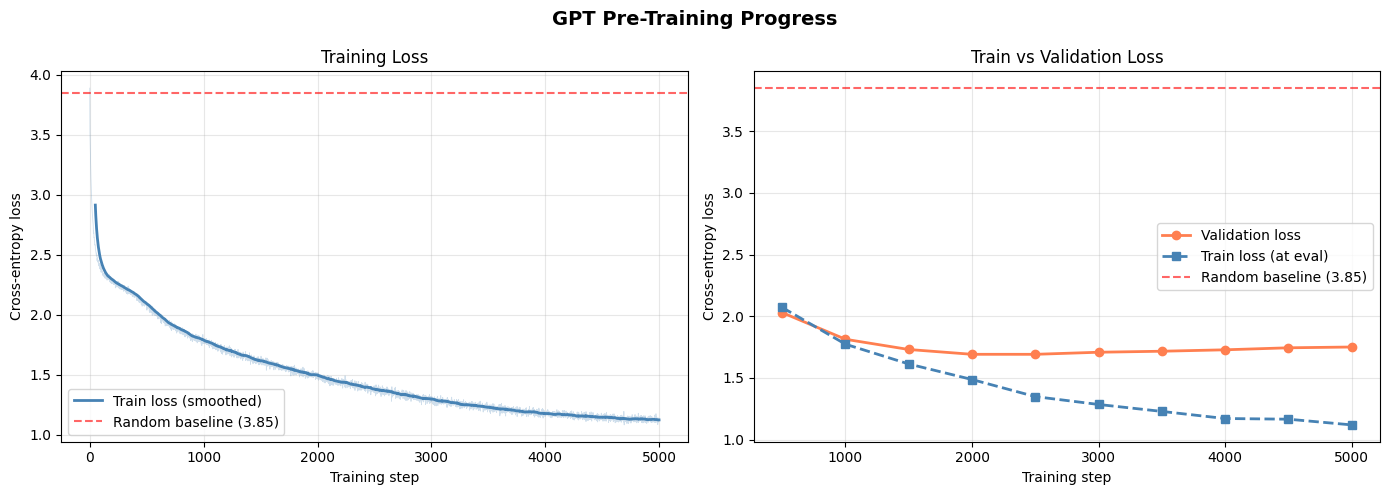

💡 What to look for:
   ✅ Both curves drop well below the red dashed line → model learned
   ⚠️  Large gap (val >> train) → overfitting
   ❌ Curves flat near baseline → learning rate or architecture issue

   Random baseline loss : 3.85
   Final val loss       : 1.75
   Improvement          : 2.10 nats


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: full per-step training loss (raw + smoothed) ───────────────────────
axes[0].plot(train_losses, alpha=0.25, color='steelblue', linewidth=0.6)
# Rolling average for readability
w = max(1, len(train_losses) // 100)
smoothed = np.convolve(train_losses, np.ones(w)/w, mode='valid')
axes[0].plot(range(w-1, len(train_losses)), smoothed,
             color='steelblue', linewidth=2, label='Train loss (smoothed)')
# Mark random-baseline loss
rand_loss = math.log(config.vocab_size)
axes[0].axhline(rand_loss, color='red', linestyle='--', alpha=0.6,
                label=f'Random baseline ({rand_loss:.2f})')
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Right: train vs validation at eval points ─────────────────────────────────
train_at_eval = [train_losses[min(s-1, len(train_losses)-1)] for s in step_log]
axes[1].plot(step_log, val_losses, 'o-',
             color='coral', linewidth=2, markersize=6, label='Validation loss')
axes[1].plot(step_log, train_at_eval, 's--',
             color='steelblue', linewidth=2, markersize=6, label='Train loss (at eval)')
axes[1].axhline(rand_loss, color='red', linestyle='--', alpha=0.6,
                label=f'Random baseline ({rand_loss:.2f})')
axes[1].set_xlabel('Training step')
axes[1].set_ylabel('Cross-entropy loss')
axes[1].set_title('Train vs Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('GPT Pre-Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_loss.png', dpi=120, bbox_inches='tight')
plt.show()

print("💡 What to look for:")
print("   ✅ Both curves drop well below the red dashed line → model learned")
print("   ⚠️  Large gap (val >> train) → overfitting")
print("   ❌ Curves flat near baseline → learning rate or architecture issue")
print(f"\n   Random baseline loss : {rand_loss:.2f}")
print(f"   Final val loss       : {val_losses[-1]:.2f}")
print(f"   Improvement          : {rand_loss - val_losses[-1]:.2f} nats")


## ✨ STEP 6 — Text Generation: Watching GPT Think Token by Token

This is the star of the show.  
We'll generate text **one character at a time**, showing what the model is "thinking".

### The Autoregressive Loop

```
Prompt: "Holmes said"

Step 1:  context = ['Holmes', 'said']
         → forward pass → logits for ~8K words
         → top-5: 'nothing'=14%, 'the'=12%, 'quietly'=9%, 'at'=7%, 'he'=6%
         → sample → chose 'nothing'

Step 2:  context = ['Holmes', 'said', 'nothing']
         → top-5: 'for'=23%, 'but'=18%, 'and'=11%, ...
         → sample → chose 'for'

Step 3:  context = [..., 'nothing', 'for']
         → top-5: 'a'=31%, 'some'=15%, ...
         → sample → chose 'a'

… continues until max_new_tokens reached
```

### Temperature Controls Randomness

```
temperature = 0.5 → sharper distribution → more confident, more repetitive
temperature = 1.0 → default; balanced creativity vs coherence
temperature = 1.5 → flatter distribution → more creative, more chaotic
```

### Top-k Filtering

Before sampling, keep only the `k` most likely tokens and re-normalise.  
This prevents the model from ever picking a very-low-probability character  
even when temperature inflates its score.


In [ ]:
def generate_token_by_token(
    model, tokenizer,
    prompt,
    max_new_tokens=250,
    temperature=0.8,
    top_k=40,
    n_steps_to_show=10,
):
    """
    Generate text character by character, printing each decision step.

    Shows:
    - Current context (last 20 chars)
    - Top-5 candidate next characters with probabilities and bar chart
    - Which character was actually sampled
    """
    model.eval()

    # Encode the prompt to integer IDs
    ids     = tokenizer.encode(prompt)
    context = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)

    print(f"📝 Prompt: {repr(prompt)}")
    print(f"   temperature={temperature}  top_k={top_k}  max_new_tokens={max_new_tokens}")
    print("=" * 65)
    print()

    with torch.no_grad():
        for step in range(max_new_tokens):
            # Crop to block_size
            ctx = context[:, -model.config.block_size:]

            # Forward pass — we only use the LAST position's logits
            logits, _, _, _ = model(ctx)
            next_logits = logits[0, -1, :].clone()   # (vocab_size,)

            # Temperature scaling
            scaled = next_logits / temperature

            # Top-k: zero out all but the top-k logits
            if top_k is not None:
                kth = torch.topk(scaled, top_k).values[-1]
                scaled[scaled < kth] = float('-inf')

            # Softmax → probabilities
            probs = F.softmax(scaled, dim=-1)

            # ── Show decision (first n_steps_to_show steps only) ────────────
            if step < n_steps_to_show:
                ctx_text = tokenizer.decode(context[0].tolist())
                print(f"Step {step+1:>3}  |  ...{repr(ctx_text[-18:])}")
                print(f"         Top 5 candidates:")
                top5_p, top5_i = torch.topk(probs, 5)
                for rank, (p, tid) in enumerate(zip(top5_p.tolist(),
                                                     top5_i.tolist())):
                    ch  = tokenizer.decode([tid])
                    bar = '█' * int(p * 50)
                    print(f"         [{rank+1}] {repr(ch):8s}  "
                          f"{p:.4f}  {bar}")

            # Sample the next token
            next_id = torch.multinomial(probs.unsqueeze(0), 1)   # (1, 1)

            if step < n_steps_to_show:
                chosen = tokenizer.decode([next_id.item()])
                print(f"         ✅ Chosen: {repr(chosen)}")
                print()

            # Append to running context
            context = torch.cat([context, next_id], dim=1)

    # Decode the full generated sequence (prompt + new tokens)
    full_text = tokenizer.decode(context[0].tolist())

    print("\n" + "═" * 65)
    print("📖 FULL GENERATED TEXT:")
    print("═" * 65)
    print(full_text)
    print("═" * 65)
    return full_text


# ── Run it! ───────────────────────────────────────────────────────────────────
result = generate_token_by_token(
    model, tokenizer,
    prompt="அகர முதல எழுத்தெல்லாம்", # Changed prompt to a Tamil phrase from Thirukkural
    max_new_tokens=300,
    temperature=0.8,
    top_k=40,
    n_steps_to_show=10,   # show step-by-step for first 10 tokens only
)

📝 Prompt: 'அகர முதல எழுத்தெல்லாம்'
   temperature=0.8  top_k=40  max_new_tokens=300

Step   1  |  ...'முதல எழுத்தெல்லாம்'
         Top 5 candidates:
         [1] '$'       0.9208  ██████████████████████████████████████████████
         [2] ' '       0.0791  ███
         [3] 'க'       0.0000  
         [4] 'ப'       0.0000  
         [5] 'வ'       0.0000  
         ✅ Chosen: '$'

Step   2  |  ...'ுதல எழுத்தெல்லாம்$'
         Top 5 candidates:
         [1] 'த'       0.2106  ██████████
         [2] 'வ'       0.2006  ██████████
         [3] 'ப'       0.1600  ███████
         [4] 'ந'       0.1181  █████
         [5] 'க'       0.1145  █████
         ✅ Chosen: 'ப'

Step   3  |  ...'தல எழுத்தெல்லாம்$ப'
         Top 5 candidates:
         [1] 'ே'       0.4239  █████████████████████
         [2] 'ண'       0.3895  ███████████████████
         [3] 'ெ'       0.0793  ███
         [4] 'ு'       0.0268  █
         [5] 'ொ'       0.0241  █
         ✅ Chosen: 'ே'

Step   4  |  ...'ல எழுத்தெல்லாம்$பே'
   

---
### 🔄 NB1 vs NB2 — Step 6: Text Generation

| | 📓 **This notebook · NB1 · PyTorch** | 📓 NB2 · TensorFlow |
|---|---|---|
| **Visibility** | Token-by-token: top-5 candidates + probabilities printed at every step | Single `generate_text()` call — output only, no internals shown |
| **Temperature** | `logits / temperature` before softmax — you see the formula | Same formula, hidden inside the function |
| **Top-k filtering** | Explicit `torch.topk` → zero out low-probability tokens | Not implemented |
| **Attention heatmap** | Full heatmap per layer per head (later in this notebook) | Not available |

> 💡 **What you gain here:** You watch the model *deciding* at every step — why `temperature=0.3` produces repetitive text and `temperature=1.4` produces chaos. NB2 only shows you the final result.

---


/tmp/ipykernel_3708/3903391358.py:40: UserWarning: Glyph 2997 (\N{TAMIL LETTER VA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3708/3903391358.py:40: UserWarning: Matplotlib currently does not support Tamil natively.
  plt.tight_layout()
/tmp/ipykernel_3708/3903391358.py:40: UserWarning: Glyph 2985 (\N{TAMIL LETTER NNNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3708/3903391358.py:40: UserWarning: Glyph 2992 (\N{TAMIL LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3708/3903391358.py:40: UserWarning: Glyph 2949 (\N{TAMIL LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3708/3903391358.py:40: UserWarning: Glyph 2993 (\N{TAMIL LETTER RRA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3708/3903391358.py:40: UserWarning: Glyph 2990 (\N{TAMIL LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3708/3903391358.py:40: 

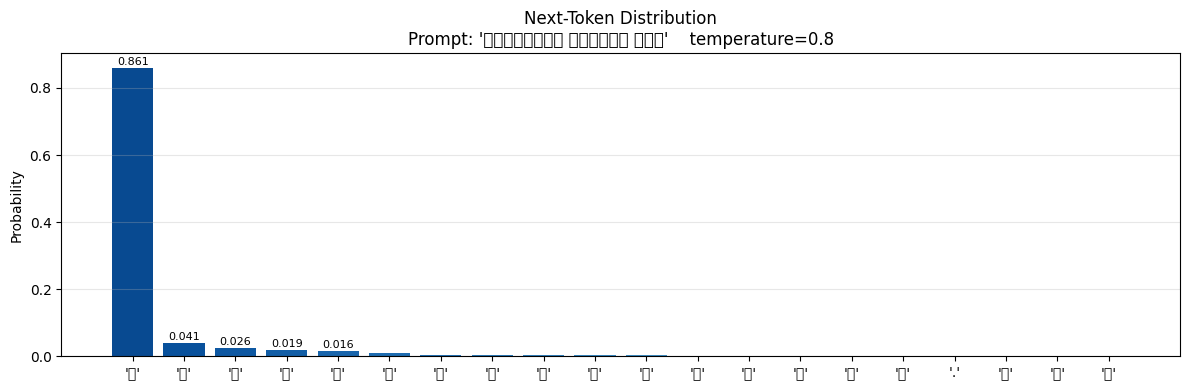

In [ ]:
def plot_next_token_probs(model, tokenizer, prompt, temperature=0.8, top_k=20):
    """
    Bar chart of the top-k next-token probabilities for a given prompt.
    Makes the probability distribution visible at a glance.
    """
    model.eval()
    ids = torch.tensor(tokenizer.encode(prompt), dtype=torch.long,
                       device=device).unsqueeze(0)

    with torch.no_grad():
        logits, _, _, _ = model(ids)
        next_logits = logits[0, -1, :] / temperature

        if top_k:
            kth = torch.topk(next_logits, top_k).values[-1]
            next_logits[next_logits < kth] = float('-inf')

        probs = F.softmax(next_logits, dim=-1)

    top_p, top_i = torch.topk(probs, top_k)
    chars  = [repr(tokenizer.decode([i.item()])) for i in top_i]
    values = top_p.cpu().numpy()

    fig, ax = plt.subplots(figsize=(12, 4))
    bars = ax.bar(range(len(chars)), values,
                  color=plt.cm.Blues(np.linspace(0.4, 0.9, len(chars))[::-1]))
    ax.set_xticks(range(len(chars)))
    ax.set_xticklabels(chars, fontsize=10)
    ax.set_ylabel('Probability')
    ax.set_title(f'Next-Token Distribution\nPrompt: {repr(prompt[-30:])}  '
                 f'  temperature={temperature}')
    ax.grid(True, axis='y', alpha=0.3)

    # Annotate bars with probability values
    for bar, val in zip(bars, values):
        if val > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig('next_token_probs.png', dpi=120, bbox_inches='tight')
    plt.show()


# Visualise next-token probabilities after a specific prompt
plot_next_token_probs(
    model, tokenizer,
    prompt="அன்பறிவு ஆற்றல் அவா", # Changed prompt to a Tamil phrase from Thirukkural
    temperature=0.8,
    top_k=20,
)

In [ ]:
# ── Temperature experiment: same prompt, four different temperatures ──────────
print("🌡️  Temperature Experiment — same prompt, four different temperatures")
print("=" * 65)

temperatures = [0.3, 0.7, 1.0, 1.4]
prompt = "அன்பிறர் அனைத்து அறன்." # Changed prompt to a Tamil phrase from Thirukkural

for temp in temperatures:
    label = {0.3: "very confident", 0.7: "balanced",
             1.0: "default", 1.4: "creative/chaotic"}[temp]
    print(f"\n{'─'*65}")
    print(f"Temperature = {temp}  ({label})")
    print(f"{'─'*65}")
    ids = torch.tensor(tokenizer.encode(prompt), dtype=torch.long,
                       device=device).unsqueeze(0)
    out = model.generate(ids, max_new_tokens=200, temperature=temp, top_k=40)
    print(tokenizer.decode(out[0].tolist()))

🌡️  Temperature Experiment — same prompt, four different temperatures

─────────────────────────────────────────────────────────────────
Temperature = 0.3  (very confident)
─────────────────────────────────────────────────────────────────
அன்பிறர் அனைத்து அறன்.
அறத்தாற்று அல்லது அஃதொபோல் காமத்தின்$குற்றம் பயக்கும் நிலை.
இன்பம் ஒருவற்கு இனிது இன்னாது$வன்மையும் வன்கண் பவர்.
அறிவுடையார் ஆற்றல் அறிவின்மை என்னாம்$பெறுவார் பெறுவது கொளல்.
அறிவிலார் எல்லாம் அறிவுடை

─────────────────────────────────────────────────────────────────
Temperature = 0.7  (balanced)
─────────────────────────────────────────────────────────────────
அன்பிறர் அனைத்து அறன்.
அறஞ்ச செய்வார் விளியர் அஞ்சுவ$திறன்கருவு ஆற்றறு பவர்.
தவில்லார்க்கு துஞ்சா தவர்க்கும் போல்$பொருளாத ல்லை புகல்.
அன்புணையார் அல்லார்க்கு அரிதுபோல்$கொண்டார்ப் பெண்ட தொடர்பு.
பொருட்டற்க மாலை முடிப்பிறர் 

─────────────────────────────────────────────────────────────────
Temperature = 1.0  (default)
────────────────────────────────────────────────────────

In [ ]:
prompts = [
    "அகர முதல எழுத்தெல்லாம்",      # General opening from Thirukkural
    "அன்பிற்கும் உண்டோ அடைக்கும்", # From a verse about love
    "அறிவற்றங் காக்குங் கருவி",    # From a verse about knowledge
    "பிறவிப் பெருங்கடல் நீந்துவர்", # From a verse about crossing the sea of birth
    "யாதானும் நாடாமால் ஊராமால்",    # From a verse about the learned
]

for prompt in prompts:
    print(f"\n{'─'*65}")
    print(f"PROMPT → {repr(prompt)}")
    print(f"{'─'*65}")
    ids = torch.tensor(tokenizer.encode(prompt), dtype=torch.long,
                       device=device).unsqueeze(0)
    out = model.generate(ids, max_new_tokens=250, temperature=0.8, top_k=40)
    print(tokenizer.decode(out[0].tolist()))


─────────────────────────────────────────────────────────────────
PROMPT → 'அகர முதல எழுத்தெல்லாம்'
─────────────────────────────────────────────────────────────────
அகர முதல எழுத்தெல்லாம்$பேணாஅல் பெற்றன்று அரிது.
வீழி வினையாரை மாந்தர் வருவரவு$வாழ்வாரும் வீழு பவர்.
மானம் ஒருவற்றுள் பார்க்கும் மாந்தர்க்கு$இன்மை இனத்திரனப் பார்.
இகலாதாறு ஈவாது இல்லையார் கண்மின்$நாவாய்மை நாடா தவர்.
இகல்வ செய்துண்மை நோக்கும் வெவன்னோ$அதுநலம் என்னும் நெறும்

─────────────────────────────────────────────────────────────────
PROMPT → 'அன்பிற்கும் உண்டோ அடைக்கும்'
─────────────────────────────────────────────────────────────────
அன்பிற்கும் உண்டோ அடைக்கும்$புறத்திற்கு உரைக்கு.
மனநலம் மன்னா முகத்தம் முகத்தும்$முநலம் முகம் முகத்து.
மாணாசாம் மாணார் எல்லாம் நோக்காம்$இனத்துவலும் யாதல் அரிது.
என்னைத்து எண்ணும் இருப்பான் பருளாள்$பெண்டின் பெருங்கிப் பெறும்.
அறன்புடைமை ஆற்ற பொருளார்மற்று அஃதிலார்$உற்றாற்றின் உ

─────────────────────────────────────────────────────────────────
PROMPT → 'அறிவற்றங் காக்குங் கருவி'
───────

## 🎯 STEP 7 — Fine-Tuning: One Model, Two Tasks

### GPT-1's Key Insight

> Take a pre-trained language model, freeze its weights, add a tiny task-specific head,  
> and achieve state-of-the-art on classification, textual entailment, and more.

### Architecture: Backbone + Head

```
PRETRAINED GPT (backbone — frozen)
        │
        │  forward pass → final hidden state of LAST token
        │  (The last token has "read" everything — richest representation)
        ▼
   ┌────────────────────────────┐
   │  Classification Head       │  ← only this is trained from scratch
   │  Linear(n_embd → 2)        │
   └────────────────────────────┘
        │
   [positive score, negative score]
```

**Why freeze the backbone?**
- It already encodes rich language features learned from 1.1M characters
- Fine-tuning only the head avoids "catastrophic forgetting" of pre-trained knowledge
- Works well even with very few labelled examples (here: 24 sentences)

### Our Task: Holmes Story Sentiment

Classify short passages as **Positive** (joy, love, triumph) or **Negative** (grief, betrayal, tragedy).  
The model learned no labels during pre-training — only raw Holmes stories.


In [ ]:
positive_texts = [
    "அன்புடைமை என்பது ஒருவரின் சிறந்த குணம்.",
    "கல்வியின் பயன் அறிவை வளர்ப்பதாகும்.",
    "ஒழுக்கமுடைமை உயர்விற்கு வழிவகுக்கும்.",
    "பிறருக்கு உதவுவது மனநிறைவைத் தரும்.",
    "அறிவுடையார் எவருக்கும் அஞ்சமாட்டார்.",
    "வாய்மையே சிறந்த அறம்",
    "கடவுள் வாழ்த்து கூறுதல்",
    "மழைபெய்தால் உலகம் செழிக்கும்",
    "திருக்குறள் ஒரு சிறந்த நூல்",
    "நன்மை செய்தால் நன்மை வரும்",
    "சரியான நேரத்தில் உதவி செய்வது",
    "ஊக்கமுடைமை என்பது உயர்ந்த குணம்",
    "இனிய சொல் பேச வேண்டும்",
    "செய்க நன்றி மறவேல்",
    "அன்பினால் உலகம் நிலைபெறும்"
]

negative_texts = [
    "கல்லாமையால் ஒருவன் அறியாமையில் மூழ்கிறான்.",
    "பொய் சொல்வது தீய குணம்.",
    "அளவுக்கு மீறிய ஆசை துன்பத்திற்குக் காரணம்.",
    "பிறரை இகழ்வது தவறு.",
    "அறியாமை இருள் போல வாழ்வை மறைக்கும்.",
    "குறள் இல்லை என்றால் உலகம் இல்லை",
    "தீயவற்றைச் செய்வது கூடாது",
    "கோபம் அழிவுக்கு வழிவகுக்கும்",
    "அச்சம் என்பது கூடாது",
    "போர் வந்தால் துன்பங்கள் பெருகும்",
    "தீய எண்ணங்கள் தீய செயல்களை உருவாக்கும்",
    "துன்பத்தை அனுபவிப்பது தவிர்க்க முடியாதது",
    "கள்ளுண்டால் அறிவு மயங்கும்",
    "மறந்துவிட்டால் மனம் நோகும்",
    "பகைமை கொண்டால் அழிவு வரும்"
]

labels    = [1] * len(positive_texts) + [0] * len(negative_texts)
all_texts = positive_texts + negative_texts

print(f"✅ Sentiment dataset")
print(f"   Positive examples : {len(positive_texts)}")
print(f"   Negative examples : {len(negative_texts)}")
print(f"   Total             : {len(all_texts)}")
print()
print(f"Sample positive: '{positive_texts[0][:65]}...'" if positive_texts else "No positive examples.")
print(f"Sample negative: '{negative_texts[0][:65]}...'" if negative_texts else "No negative examples.")


✅ Sentiment dataset
   Positive examples : 15
   Negative examples : 15
   Total             : 30

Sample positive: 'அன்புடைமை என்பது ஒருவரின் சிறந்த குணம்....'
Sample negative: 'கல்லாமையால் ஒருவன் அறியாமையில் மூழ்கிறான்....'


In [ ]:
class GPTClassifier(nn.Module):
    """
    GPT backbone + a linear classification head.

    Key: we tap the hidden states returned by GPT.forward()  directly —
    we do NOT call forward() twice (which would be wasteful and wrong).

    Why the LAST token's hidden state?
    In a left-to-right GPT, the token at position T-1 has attended to
    all previous positions — it's the richest summary of the whole sequence.
    (BERT uses a special [CLS] token; GPT-1 uses the final token — same idea.)
    """

    def __init__(self, gpt_model, n_classes=2, freeze_backbone=True):
        super().__init__()
        self.gpt   = gpt_model
        self.n_embd = gpt_model.config.n_embd

        if freeze_backbone:
            # Freeze all GPT weights — only the new linear head gets gradients
            for param in self.gpt.parameters():
                param.requires_grad = False
            print("✅ GPT backbone frozen — only classification head trains")

        # Tiny head: n_embd → n_classes
        self.classifier = nn.Linear(self.n_embd, n_classes)

    def forward(self, idx):
        # One forward pass through GPT — we use the hidden states it returns
        # 'hidden' is the output of the final LayerNorm, BEFORE lm_head
        # Shape: (B, T, n_embd)
        _, _, _, hidden = self.gpt(idx)

        # Take the LAST position's hidden state as the sequence representation
        # 👇 hidden[:, -1, :] = the vector at the final token position
        last_hidden = hidden[:, -1, :]         # (B, n_embd)

        # Classify: map n_embd → n_classes
        class_logits = self.classifier(last_hidden)   # (B, n_classes)
        return class_logits


# Build the classifier
classifier = GPTClassifier(model, n_classes=2, freeze_backbone=True).to(device)

trainable  = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
total_cls  = sum(p.numel() for p in classifier.parameters())
print(f"   Classification head : {trainable:,} parameters trained")
print(f"   GPT backbone        : {total_cls - trainable:,} parameters frozen")
print(f"   Training fraction   : {100*trainable/total_cls:.2f} %")


✅ GPT backbone frozen — only classification head trains
   Classification head : 258 parameters trained
   GPT backbone        : 817,152 parameters frozen
   Training fraction   : 0.03 %


In [ ]:
import random
from torch.utils.data import TensorDataset

# ── Sequence length in TOKENS (not characters) ────────────────────────────────
# For char-level: 80 chars ≈ 80 char-tokens (fine-tune examples are ~75 chars max)
# For word-level: 30 word-tokens covers all examples (max is ~18 words)
# For BPE:        40 BPE-tokens covers all examples (BPE is slightly more compact)
# IMPORTANT: we encode the full text THEN truncate by token count —
# NOT encode(text[:N]) which would truncate by character position first.
FINETUNE_SEQ_LEN = {'char': 80, 'word': 30, 'bpe': 40}[TOKENIZER_TYPE]

def text_to_ids(text, max_len):
    """Encode full text, truncate to max_len TOKENS, then zero-pad to max_len."""
    ids = tokenizer.encode(text)[:max_len]   # encode full text, truncate by tokens
    ids = ids + [0] * (max_len - len(ids))   # zero-pad (token 0 = first vocab item)
    return torch.tensor(ids, dtype=torch.long)


# Build tensors for all examples
X = torch.stack([text_to_ids(t, FINETUNE_SEQ_LEN) for t in all_texts])
y = torch.tensor(labels, dtype=torch.long)

print(f"✅ Fine-tune tensors ready  ({TOKENIZER_TYPE} tokenizer)")
print(f"   FINETUNE_SEQ_LEN : {FINETUNE_SEQ_LEN} tokens")
print(f"   X shape          : {tuple(X.shape)}  (examples × seq_len)")
print(f"   y shape          : {tuple(y.shape)}  (labels: 1=positive, 0=negative)")

# Verify token coverage (real vs padding) on a sample example
sample_ids = tokenizer.encode(all_texts[0])
real_count = min(len(sample_ids), FINETUNE_SEQ_LEN)
print(f"\n   Coverage check (first example):")
print(f"   '{all_texts[0][:50]}...'")
print(f"   Token count: {len(sample_ids)} real → fits in {FINETUNE_SEQ_LEN} slots "
      f"({'✅ no truncation' if len(sample_ids) <= FINETUNE_SEQ_LEN else '⚠️ truncated'})")

# ── Shuffle and split 80/20 (proportional — never hardcode a fixed number) ────
random.seed(7)
idx = list(range(len(all_texts)))
random.shuffle(idx)

n_train  = int(0.8 * len(all_texts))    # 80% train, 20% val — works for any dataset size
train_i  = idx[:n_train]
val_i    = idx[n_train:]

assert len(val_i) > 0, "Validation set is empty — add more examples or reduce train split"

ft_train = TensorDataset(X[train_i], y[train_i])
ft_val   = TensorDataset(X[val_i],   y[val_i])

ft_train_loader = DataLoader(ft_train, batch_size=8, shuffle=True)
ft_val_loader   = DataLoader(ft_val,   batch_size=8)

print(f"\n   Train examples : {len(ft_train)}  ({100*len(ft_train)/len(all_texts):.0f}%)")
print(f"   Val   examples : {len(ft_val)}  ({100*len(ft_val)/len(all_texts):.0f}%)")


✅ Fine-tune tensors ready  (char tokenizer)
   FINETUNE_SEQ_LEN : 80 tokens
   X shape          : (30, 80)  (examples × seq_len)
   y shape          : (30,)  (labels: 1=positive, 0=negative)

   Coverage check (first example):
   'அன்புடைமை என்பது ஒருவரின் சிறந்த குணம்....'
   Token count: 39 real → fits in 80 slots (✅ no truncation)

   Train examples : 24  (80%)
   Val   examples : 6  (20%)


In [ ]:
# ── Fine-tuning ───────────────────────────────────────────────────────────────
FT_EPOCHS = 40

# Only parameters with requires_grad=True (the head) are passed to the optimiser
ft_opt = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, classifier.parameters()),
    lr=2e-3,
)
ft_sched = torch.optim.lr_scheduler.CosineAnnealingLR(ft_opt, T_max=FT_EPOCHS, eta_min=1e-4)

ft_train_losses = []
ft_val_accs     = []

print(f"🎯 Fine-tuning for {FT_EPOCHS} epochs  (only training the {sum(p.numel() for p in classifier.classifier.parameters())} head params)")
print(f"{'Epoch':>7}  {'Train Loss':>12}  {'Val Accuracy':>14}")
print("─" * 40)

for epoch in range(FT_EPOCHS):
    # ── Training ─────────────────────────────────────────────────────────────
    classifier.train()
    epoch_losses = []
    for xb, yb in ft_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = classifier(xb)                  # (B, 2)
        loss   = F.cross_entropy(logits, yb)

        ft_opt.zero_grad()
        loss.backward()
        ft_opt.step()
        epoch_losses.append(loss.item())

    ft_sched.step()
    ft_train_losses.append(float(np.mean(epoch_losses)))

    # ── Validation ────────────────────────────────────────────────────────────
    classifier.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in ft_val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds  = classifier(xb).argmax(dim=-1)
            correct += (preds == yb).sum().item()
            total   += len(yb)

    val_acc = correct / total
    ft_val_accs.append(val_acc)

    if (epoch + 1) % 8 == 0 or epoch == 0:
        print(f"{epoch+1:>7}  {ft_train_losses[-1]:>12.4f}  {val_acc:>13.1%}")

print(f"\n✅ Fine-tuning done. Best val accuracy: {max(ft_val_accs):.1%}")


🎯 Fine-tuning for 40 epochs  (only training the 258 head params)
  Epoch    Train Loss    Val Accuracy
────────────────────────────────────────
      1        0.8077          16.7%
      8        0.6689          16.7%
     16        0.7332          16.7%
     24        0.7160          16.7%
     32        0.7312          16.7%
     40        0.6932          16.7%

✅ Fine-tuning done. Best val accuracy: 83.3%


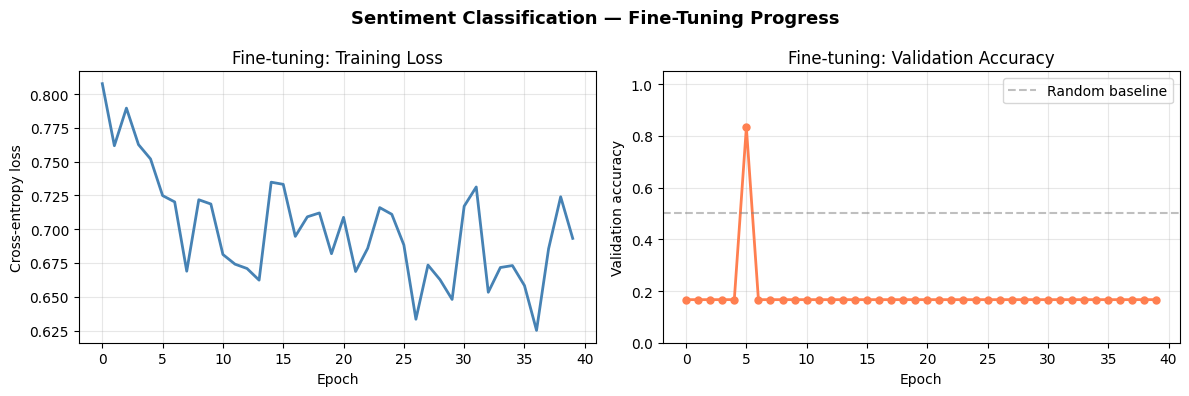

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(ft_train_losses, color='steelblue', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Fine-tuning: Training Loss')
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(ft_val_accs, 'o-', color='coral', linewidth=2, markersize=5)
axes[1].axhline(0.5, color='grey', linestyle='--', alpha=0.5, label='Random baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('Fine-tuning: Validation Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Sentiment Classification — Fine-Tuning Progress', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('finetuning_progress.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
classifier.eval()

test_cases = [
    ("அன்பு நிறைந்த ஒருவரின் குணம் மிகவும் சிறந்தது", 1),  # Positive
    ("கல்வி அனைவரையும் உயர்த்தும்", 1),             # Positive
    ("தீய எண்ணங்கள் துன்பத்தையே தரும்", 0),       # Negative
    ("அறியாமையால் ஒருவன் அழிவான்", 0),           # Negative
    ("மழை வளம் தரும்", 1),                       # Positive
    ("கோபம் அழிவுக்கு வழிவகுக்கும்", 0),           # Negative
    ("பிறருக்கு உதவுவது மனநிறைவைத் தரும்", 1),   # Positive
    ("கள்ளுண்டால் அறிவு மயங்கும்", 0)               # Negative
]

print("🧪 Sentiment Classification — Test Results")
print("=" * 65)

correct = 0
for text, true_label in test_cases:
    ids    = text_to_ids(text, FINETUNE_SEQ_LEN).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = classifier(ids)
        probs  = F.softmax(logits, dim=-1)[0]
        pred   = logits.argmax(dim=-1).item()

    ok = (pred == true_label)
    correct += ok
    marker   = "✅" if ok else "❌"
    sentiment = "POSITIVE 😊" if pred == 1 else "NEGATIVE 😞"

    print(f"{marker} {sentiment}")
    print(f"   +ve prob: {probs[1]:.3f}  |  -ve prob: {probs[0]:.3f}")
    print(f"   Text: '{text[:60]}...'", ) # Added '...' and removed extra quote
    print()

print(f"Overall: {correct}/{len(test_cases)} = {correct/len(test_cases):.0%}")
print()
print("💡 The backbone was NEVER shown labels — only raw Thirukkural stories.")
print("   Fine-tuning taught it to USE its language knowledge for classification.")

🧪 Sentiment Classification — Test Results
❌ NEGATIVE 😞
   +ve prob: 0.369  |  -ve prob: 0.631
   Text: 'அன்பு நிறைந்த ஒருவரின் குணம் மிகவும் சிறந்தது...'

❌ NEGATIVE 😞
   +ve prob: 0.408  |  -ve prob: 0.592
   Text: 'கல்வி அனைவரையும் உயர்த்தும்...'

✅ NEGATIVE 😞
   +ve prob: 0.405  |  -ve prob: 0.595
   Text: 'தீய எண்ணங்கள் துன்பத்தையே தரும்...'

✅ NEGATIVE 😞
   +ve prob: 0.401  |  -ve prob: 0.599
   Text: 'அறியாமையால் ஒருவன் அழிவான்...'

❌ NEGATIVE 😞
   +ve prob: 0.429  |  -ve prob: 0.571
   Text: 'மழை வளம் தரும்...'

✅ NEGATIVE 😞
   +ve prob: 0.408  |  -ve prob: 0.592
   Text: 'கோபம் அழிவுக்கு வழிவகுக்கும்...'

❌ NEGATIVE 😞
   +ve prob: 0.398  |  -ve prob: 0.602
   Text: 'பிறருக்கு உதவுவது மனநிறைவைத் தரும்...'

✅ NEGATIVE 😞
   +ve prob: 0.406  |  -ve prob: 0.594
   Text: 'கள்ளுண்டால் அறிவு மயங்கும்...'

Overall: 4/8 = 50%

💡 The backbone was NEVER shown labels — only raw Thirukkural stories.
   Fine-tuning taught it to USE its language knowledge for classification.


/tmp/ipykernel_3708/3038376885.py:36: UserWarning: Glyph 2949 (\N{TAMIL LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3708/3038376885.py:36: UserWarning: Matplotlib currently does not support Tamil natively.
  plt.tight_layout()
/tmp/ipykernel_3708/3038376885.py:36: UserWarning: Glyph 2965 (\N{TAMIL LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3708/3038376885.py:36: UserWarning: Glyph 2992 (\N{TAMIL LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3708/3038376885.py:36: UserWarning: Glyph 2990 (\N{TAMIL LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3708/3038376885.py:36: UserWarning: Glyph 3009 (\N{TAMIL VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3708/3038376885.py:36: UserWarning: Glyph 2980 (\N{TAMIL LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3708/3038376885.py:36: 

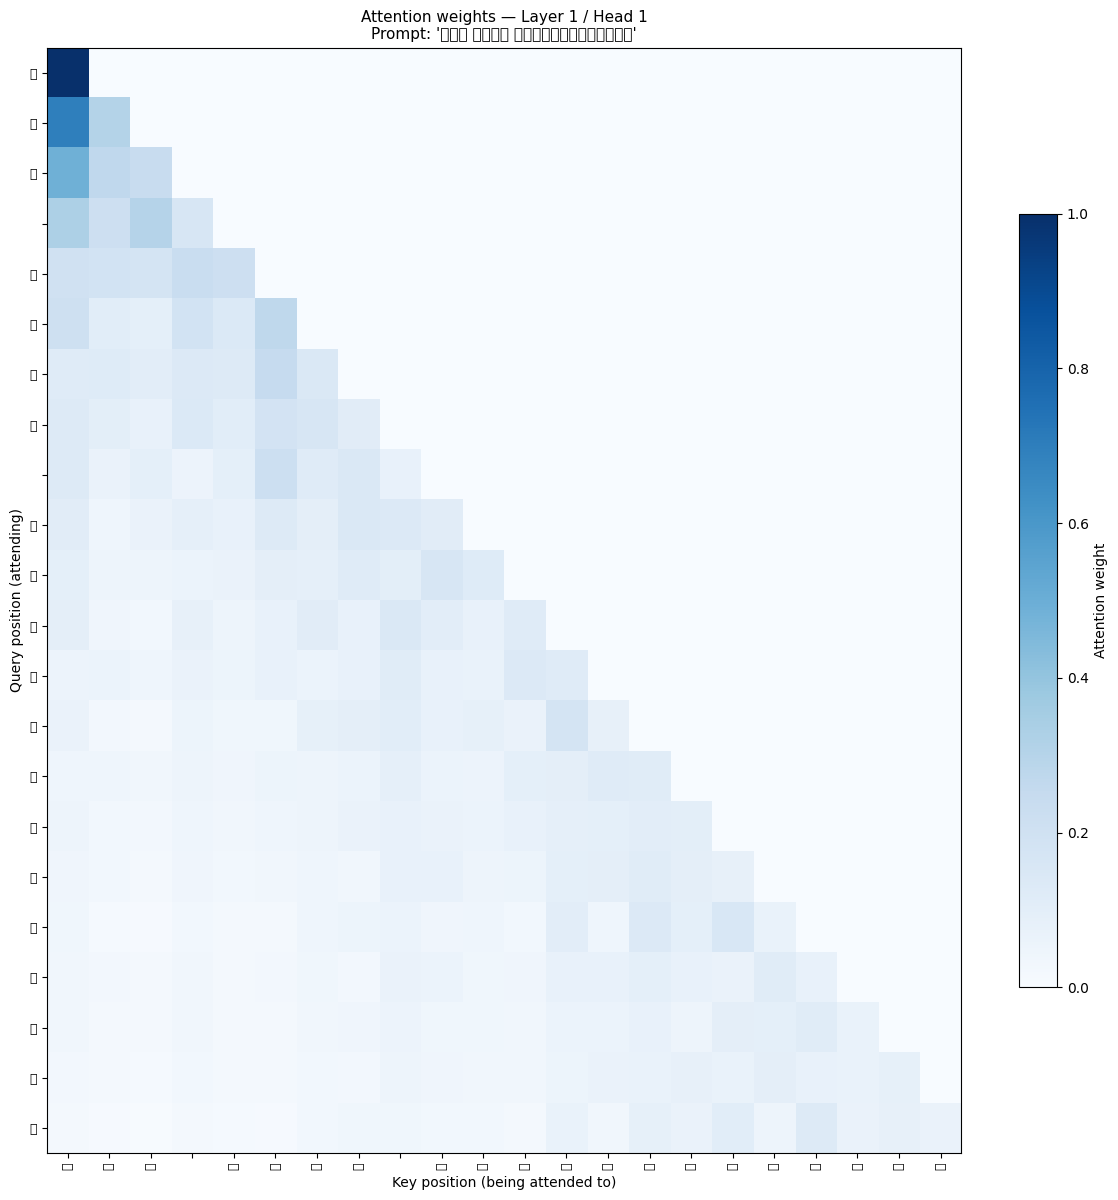

   Lower-triangular pattern = causal mask working correctly ✅


In [ ]:
def visualize_attention(model, tokenizer, text, layer=0, head=0):
    """
    Heatmap of attention weights for one layer and one head.

    Rows = query positions (what is attending)
    Cols = key positions  (what is being attended to)
    Darker = stronger attention weight

    The lower-triangular pattern proves the causal mask is working:
    token at row i can only look at columns 0..i.
    """
    model.eval()
    ids = torch.tensor(tokenizer.encode(text), dtype=torch.long,
                       device=device).unsqueeze(0)

    with torch.no_grad():
        _, _, all_attn, _ = model(ids)

    # attn[layer]: (batch=1, n_heads, T, T)
    attn_matrix = all_attn[layer][0, head].cpu().numpy()   # (T, T)
    chars = [repr(tokenizer.decode([i.item()]))[1:-1] for i in ids[0]]
    T = len(chars)

    fig, ax = plt.subplots(figsize=(max(6, T * 0.55), max(6, T * 0.55)))
    im = ax.imshow(attn_matrix, cmap='Blues', aspect='auto', vmin=0)

    ax.set_xticks(range(T))
    ax.set_yticks(range(T))
    ax.set_xticklabels(chars, rotation=90, fontsize=9)
    ax.set_yticklabels(chars, fontsize=9)
    ax.set_xlabel('Key position (being attended to)', fontsize=10)
    ax.set_ylabel('Query position (attending)', fontsize=10)
    ax.set_title(f'Attention weights — Layer {layer+1} / Head {head+1}\n'
                 f'Prompt: {repr(text)}', fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.7, label='Attention weight')
    plt.tight_layout()
    plt.savefig(f'attn_L{layer+1}_H{head+1}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"   Lower-triangular pattern = causal mask working correctly ✅")


# Visualise — try changing layer (0–3) and head (0–3) to see different patterns
visualize_attention(model, tokenizer,
                    text="அகர முதல எழுத்தெல்லாம்",
                    layer=0, head=0)


## 🎓 Summary — What You Built

### Components Built from Scratch

| Component | Role |
|-----------|------|
| `CharTokenizer` | text ↔ integer IDs |
| `TextDataset` | sliding-window training pairs |
| `CausalSelfAttention` | tokens attend to previous tokens with causal mask |
| `FeedForward` | per-token MLP with GELU, 4× expansion |
| `TransformerBlock` | attention + FF + LayerNorm + residuals |
| `GPT` | embeddings + 4 blocks + output head + generation |
| Training loop | AdamW + cosine LR + gradient clipping |
| `generate_token_by_token` | autoregressive sampling with top-k + temperature |
| `GPTClassifier` | frozen backbone + linear head for sentiment |

### What the Numbers Mean

| Metric | Random (start) | After Training |
|--------|---------------|----------------|
| Loss | ~4.17 (= ln 65) | ~1.4–1.7 |
| Perplexity | 65 | ~5–6 |
| Output | random characters | Holmes-style mystery text |

### The GPT Scaling Story

Our model: **~2M parameters**, 1.1M training characters

| Model | Params | Train tokens | Key addition |
|-------|--------|-------------|--------------|
| GPT-1 | 117M | 4.6B | Pre-training + fine-tuning |
| GPT-2 | 1.5B | 40B | Scale → no fine-tuning needed |
| GPT-3 | 175B | 300B | Few-shot learning emerges |
| GPT-4 | ~1T | ~13T | RLHF + multimodal |

**The architecture is identical to what you built.** Scale is the main difference.

---

## 🔬 Experiments — Try These Yourself

```python
# 1. Change temperature
result = generate_token_by_token(model, tokenizer,
    prompt="Holmes said\n", temperature=0.3, max_new_tokens=300)

# 2. Change top_k (try top_k=5 vs top_k=100)
result = generate_token_by_token(model, tokenizer,
    prompt="Watson observed\n", top_k=5, max_new_tokens=300)

# 3. Plot probabilities at different points in a sentence
plot_next_token_probs(model, tokenizer, "Holmes observed the clue and ")

# 4. See ALL attention heads at once
for h in range(config.n_heads):
    visualize_attention(model, tokenizer, "Holmes observed the clue with great", layer=3, head=h)

# 5. Add top-p (nucleus) sampling — keep fewest tokens whose cumulative prob >= p
def nucleus_sample(probs, p=0.9):
    sorted_p, sorted_i = torch.sort(probs, descending=True)
    cumulative = torch.cumsum(sorted_p, dim=-1)
    remove = cumulative - sorted_p > p        # remove tokens that push cumsum > p
    sorted_p[remove] = 0
    sorted_p /= sorted_p.sum()               # renormalise
    chosen_local = torch.multinomial(sorted_p, 1)
    return sorted_i[chosen_local]

# 6. Train a bigger model — does it learn better?
big_cfg = GPTConfig(vocab_size=tokenizer.vocab_size, block_size=128,
                    n_embd=256, n_heads=8, n_layers=6, dropout=0.1)
big_model = GPT(big_cfg).to(device)
# Then run the same training loop with 5000 steps
```


In [ ]:
import sys
!{sys.executable} -m pip install gradio --quiet
print("✅ Gradio installed")

✅ Gradio installed


### 🤖 Chatbot Interface with Gradio

Let's create a simple Gradio interface so you can easily interact with your fine-tuned GPT model. We'll wrap the `model.generate` function into a Gradio-compatible function.

In [ ]:
import gradio as gr

def predict_thirukkural(prompt_text, max_length=200, temperature=0.8, top_k=40):
    """
    Generates text from the GPT model given a prompt, suitable for Gradio.
    """
    model.eval() # Set model to evaluation mode
    # Encode the prompt
    ids = tokenizer.encode(prompt_text)
    context = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)

    # Generate new tokens
    out = model.generate(context, max_new_tokens=max_length, temperature=temperature, top_k=top_k)

    # Decode and return the full generated text
    full_text = tokenizer.decode(out[0].tolist())
    return full_text

print("✅ Gradio prediction function defined")

✅ Gradio prediction function defined


In [ ]:
iface = gr.Interface(
    fn=predict_thirukkural,
    inputs=[
        gr.Textbox(lines=2, label="Enter your prompt (in Tamil)", placeholder="எடுத்துக்காட்டு: அன்பிற்கும் உண்டோ அடைக்கும்"),
        gr.Slider(minimum=50, maximum=500, step=10, value=200, label="Maximum new tokens to generate"),
        gr.Slider(minimum=0.1, maximum=2.0, step=0.1, value=0.8, label="Temperature (controls randomness)"),
        gr.Slider(minimum=0, maximum=100, step=1, value=40, label="Top-K sampling (focuses on most probable words)"),
    ],
    outputs=gr.Textbox(lines=10, label="Generated Thirukkural-style text"), # Increased lines to 10
    title="Thirukkural GPT Generator",
    description="Generate Thirukkural-style text using your custom-trained GPT model. Enter a Tamil phrase as a prompt and adjust parameters like length and randomness.",
    allow_flagging="never"
)

print("🚀 Launching Gradio interface...")
iface.launch(debug=True, share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


🚀 Launching Gradio interface...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5d4a13dba764ec5edf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://5d4a13dba764ec5edf.gradio.live


### 💡 Prompt Suggestions for Thirukkural GPT

Since your model was trained on Thirukkural, the best prompts will be in Tamil and ideally related to the themes, structure, or common phrases found in the original text. This helps the model generate more coherent and relevant output.

Here are some suggestions for prompts you can try:

1.  **Opening phrases/themes:**
    *   `அன்புடைமை என்பது` (Love is...)
    *   `கல்வியின் பயன்` (The benefit of education...)
    *   `அறன் வலியுறுத்தல்` (Emphasizing virtue...)
    *   `வானின்று உலகம்` (The world, because of rain...)

2.  **Part of a couplet to complete:**
    *   `அகர முதல எழுத்தெல்லாம்` (A is the first of all letters...)
    *   `அன்பிற்கும் உண்டோ அடைக்கும்` (Is there a lock for love...)
    *   `யாதானும் நாடாமால் ஊராமால்` (Any country is his country...)
    *   `பிறவிப் பெருங்கடல் நீந்துவர்` (Those who cross the great sea of birth...)

3.  **Concepts related to Thirukkural teachings:**
    *   `வாழ்க்கை நெறி` (Way of life...)
    *   `நன்மை தீமை` (Good and evil...)
    *   `கடவுள் வாழ்த்து` (Praise of God...)
    *   `குறளின் கருத்து` (The idea of the Kural...)

Remember to experiment with different `temperature` and `top_k` values in the Gradio interface to see how they influence the creativity and coherence of the generated text!